# 8/2026 Analysis of Brain Slice Data  
Want to visualize post stimulus response at 1 Hz, 10 Hz, and 20 Hz  
  
### Imports:  
- HDF5 pluggin must be specified **before** any spikeinterface imports

In [1]:
# --- Standard Library -------------------------------------------------------
import json 
import os
import sys
from pathlib import Path

CONFIG_PATH = Path.home() / ".acute_slice_mea" / "paths.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config file: {CONFIG_PATH}\n")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    USER_PATHS = json.load(f)

plugin_raw = USER_PATHS.get("hdf5_plugin_path")
if plugin_raw:
    plugin_path = Path(plugin_raw).expanduser()
    if not plugin_path.exists():
        raise FileNotFoundError("hdf5_plugin_path does not exist")
    os.environ["HDF5_PLUGIN_PATH"] = str(plugin_path)

local_path = Path(USER_PATHS["recording_file"]).expanduser()
OUTPUT_DIR = Path(USER_PATHS["output_dir"]).expanduser()

print(f"Using config: {CONFIG_PATH}")
print(f"HDF5 plugin path: {plugin_path}")
print(f"Recoding file: {local_path}")
print(f"Output directory: {OUTPUT_DIR}")

Using config: C:\Users\dkhun\.acute_slice_mea\paths.json
HDF5 plugin path: C:\Users\dkhun\hdf5_plugins
Recoding file: C:\Users\dkhun\UCDavis\BenShalomLab\BSlice_raw_data\Experiment4_Slice2_layer1_1minbaseline_1hz_10hz_20hz.raw.h5
Output directory: C:\Users\dkhun\UCDavis\BenShalomLab\Analysis_pictures


In [2]:
# ==============================================================================
# IMPORTS: Organized by Standard Library, Third-Party, and Local modules
# ==============================================================================

# --- Third-Party Libraries --------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.signal import find_peaks
import ipywidgets as widgets
from IPython.display import display

# --- SpikeInterface (Data Loading & Processing) ----------------------------
import spikeinterface
import spikeinterface.full as si
import spikeinterface.extractors as se
import spikeinterface.widgets as sw
import spikeinterface.preprocessing as spre


In [3]:
recording1 = se.read_maxwell(local_path,stream_id = 'well000')
freq_min = 0.5
freq_max = 300


#recording = si.ConcatenateSegmentRecording([recording1,recording2])
channel_ids = recording1.get_channel_ids()
fs = recording1.get_sampling_frequency()
num_chan = recording1.get_num_channels()
num_seg = recording1.get_num_segments()
total_recording = recording1.get_total_duration()   # in seconds
start_chunk = 0
end_chunk = total_recording


# --- Add file name ---
file_name = os.path.basename(local_path) if 'local_path' in globals() else "Unknown file"

#print('Channel ids:', channel_ids)'
print(f'Local Path: {os.path.dirname(local_path)}/')
print(f'File: {file_name}')
print(f'Sampling frequency: {fs} Hz')
print(f'Number of channels: {num_chan}')
print(f'Number of segments: {num_seg}')
print(f"total_recording: {total_recording} s")

recording_signed = si.unsigned_to_signed(recording1)

recording_bp = spre.bandpass_filter(recording_signed, freq_min=freq_min, freq_max=freq_max)

recording_cmr = spre.common_reference(recording_bp, reference='global', operator='median')
# recording_chunk = recording_cmr.frame_slice(start_frame= 1*fs,end_frame=425*fs)
# recording_chunk = recording_cmr.frame_slice(start_frame= 0*fs,end_frame=25*fs)
recording_chunk = recording_bp.frame_slice(start_frame= start_chunk*fs,end_frame=end_chunk*fs)

print(f"chunk duration: {recording_chunk.get_total_duration()} s")

The h5 compression library for Maxwell is already located in C:\Users\dkhun\hdf5_plugins\compression.dll!
Local Path: C:\Users\dkhun\UCDavis\BenShalomLab\BSlice_raw_data/
File: Experiment4_Slice2_layer1_1minbaseline_1hz_10hz_20hz.raw.h5
Sampling frequency: 20000.0 Hz
Number of channels: 939
Number of segments: 1
total_recording: 270.75 s
chunk duration: 270.75 s


### **Visualize the stimulation array:**  
- Wide part is stimulation site of brainslice (layer unknown)
- Optional, but quick


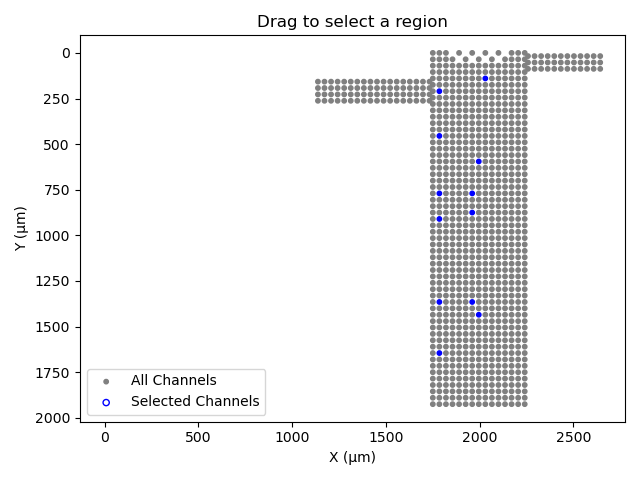

In [ ]:
import os
from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import numpy as np
import pandas as pd

%matplotlib widget
# Get channel coordinates
locs = recording_chunk.get_channel_locations()
channel_ids = recording_chunk.get_channel_ids()

channels_to_highlight = ['821','148','532','296','258','766']  # Example channels to highlight
middle_channels = ['1000','72','16','13','197','622']
channels_to_highlight.extend(ch for ch in middle_channels)

# Setup figure
fig, ax = plt.subplots()
c = ['gray'] * len(channel_ids)  # Default color for all channels
for ch in channels_to_highlight:
  if ch in channel_ids:
    idx = np.where(channel_ids == ch)[0][0]
    c[idx] = 'blue'  # Highlight specified channels in blue

sc = ax.scatter(locs[:, 0], locs[:, 1], c=c, label='All Channels', s=10)
ax.set_title('Drag to select a region')
ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')

# Scatter for selected points
selected_plot = ax.scatter(
    [],
    [],
    facecolors='none',
    edgecolors='blue',
    linewidths=1,
    s=20,
    label='Selected Channels',
)
selected_channels = np.array([])  # Initialize as array

# Create an output widget for displaying messages
output = widgets.Output()


# Helper function to sort channel IDs top-to-bottom (-Y) then left-to-right (+X)
def sort_channels_spatially(chs_to_sort):
  if len(chs_to_sort) == 0:
    return np.array([])

  # Get indices of these channels in channel_ids
  mask = np.isin(channel_ids, chs_to_sort)
  sel_ids = channel_ids[mask]
  sel_locs = locs[mask]

  # Sort key: primary = -Y (highest Y first / top-to-bottom), secondary = +X (left-to-right)
  sort_indices = np.lexsort((sel_locs[:, 0], sel_locs[:, 1]))

  return sel_ids[sort_indices]


# Selection callback with cumulative selection
def onselect(eclick, erelease):
  global selected_channels
  if (eclick.xdata is None or erelease.xdata is None):  # Ignore clicks outside the plot
    return

  x0, y0 = eclick.xdata, eclick.ydata
  x1, y1 = erelease.xdata, erelease.ydata

  mask = (
      (locs[:, 0] > min(x0, x1))
      & (locs[:, 0] < max(x0, x1))
      & (locs[:, 1] > min(y0, y1))
      & (locs[:, 1] < max(y0, y1))
  )
  new_selection = channel_ids[mask]

  # Combine selections
  if eclick.key == 'control':  # Append to existing selection
    combined = np.concatenate((selected_channels, new_selection))
    # Deduplicate while preserving spatial order via lookup
    unique_chs = np.unique(combined)
    selected_channels = sort_channels_spatially(unique_chs)
  else:  # Overwrite selection
    selected_channels = sort_channels_spatially(new_selection)

  selected_plot.set_offsets(locs[np.isin(channel_ids, selected_channels)])
  fig.canvas.draw_idle()

  # Display the selection details in the output widget
  with output:
    output.clear_output()  # Clear previous messages
    print(f'🔴 Selected {len(selected_channels)} channels')
    print(', '.join(f"'{s}'" for s in selected_channels.tolist()))


# Create RectangleSelector
selector = RectangleSelector(
    ax, onselect, interactive=True, useblit=True, button=[1]
)

# Create save button
save_button = widgets.Button(
    description='💾 Save Selected Channels',
    button_style='success',
    tooltip='Save selected channel IDs to file',
)


# Define callback to save to file
def save_selected_channels_to_file(b):
  if len(selected_channels) == 0:
    with output:
      output.clear_output()
      print('⚠️ No channels selected to save.')
    return

  save_path = 'selected_channels.txt'

  # Format each channel ID as a quoted string: 'channel_id'
  formatted_list = [f"'{ch}'" for ch in selected_channels]
  chunk_size = 20
  lines = []
  for i in range(0, len(formatted_list), chunk_size):
    chunk = formatted_list[i : i + chunk_size]
    lines.append('    ' + ', '.join(chunk))

  list_content = '[\n' + ',\n'.join(lines) + '\n]'

  try:
    with open(save_path, 'w') as f:
      f.write(list_content)

    with output:
      output.clear_output()
      print(f'✅ Successfully saved {len(selected_channels)} channels to:')
      print(f'   📁 {os.path.abspath(save_path)}')
  except Exception as e:
    with output:
      output.clear_output()
      print(f'❌ Error saving file: {str(e)}')
      

# Attach callback and show button
save_button.on_click(save_selected_channels_to_file)

# Display the save button and output widget
display(widgets.VBox([save_button, output]))
ax.invert_yaxis()  # Invert y-axis to match MEA layout

plt.legend()
plt.tight_layout()
plt.show()

### **Plot a single trace:**  
- Verify data from 1 channel  
    - 
- Extract 'CONDITIONS' blocks for timing, frequency  
    - CONDITIONS block applies to all channels
- 1.5 min runtime

Stim trace range: 635.7 to 5488.6 µV
Total stim pulses detected: 930

Detected 3 condition blocks (gaps > 4 s):
Block     t_start (s)    t_end (s)   n_pulses   amp_min (µV)   amp_max (µV)
------------------------------------------------------------------------
  1             60.45        89.46         30          667.2          742.7
  2            124.89       154.91        300          635.7          742.7
  3            180.97       211.16        600          635.7          786.8


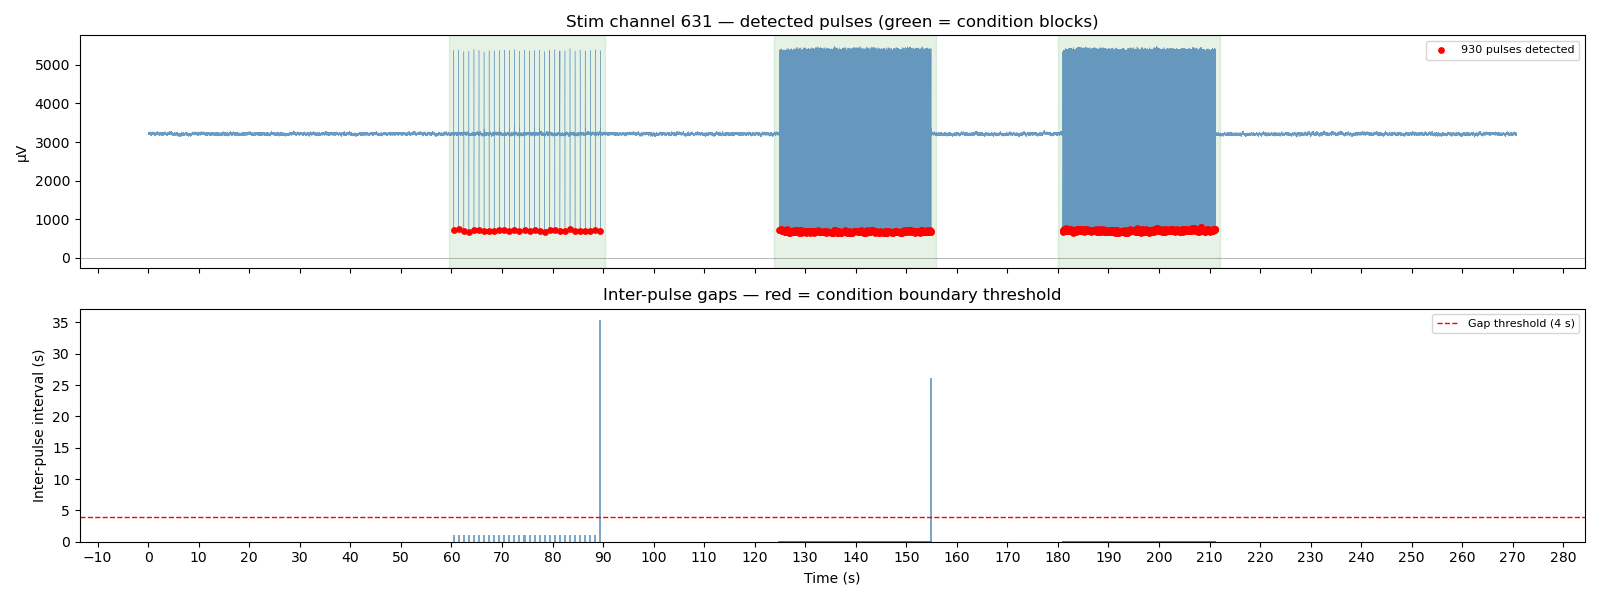


# ── Paste into your analysis cell ──
CONDITIONS = [
    ('Cond 1',  59.5,  90.5),   # 30 pulses
    ('Cond 2',  123.9,  155.9),   # 300 pulses
    ('Cond 3',  180.0,  212.2),   # 600 pulses
]


In [6]:
# ============================================================
# STEP 0 — Find condition boundaries from STIM CHANNEL
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks

STIM_CHANNEL_ID  = '631'     # one stim channel
MIN_INTERVAL_S   = 0.005      # min seconds between pulses within a condition
GAP_THRESHOLD_S  = 4 # gaps longer than this = new condition block
height = 500  # µV — stim artifact is large, tune if needed

FILTERED = False
rec = recording_chunk if FILTERED else recording1

fs     = rec.get_sampling_frequency()
n_samp = rec.get_num_frames()

stim_trace = rec.get_traces(
    channel_ids=[STIM_CHANNEL_ID], return_in_uV=True
).squeeze()

print(f"Stim trace range: {stim_trace.min():.1f} to {stim_trace.max():.1f} µV")

stim_centered = stim_trace - np.median(stim_trace)
# Stim channel artifact is typically a large negative peak after signing
peak_idxs, _ = find_peaks(
    -stim_centered,
    height=height,                          # µV — stim artifact is large, tune if needed
    distance=int(MIN_INTERVAL_S * fs),
    prominence=70,
)

peak_times_s = peak_idxs / fs
peak_amps    = stim_trace[peak_idxs]

print(f"Total stim pulses detected: {len(peak_idxs)}")

# ── Split into condition blocks by gap ───────────────────────
inter_peak_gaps = np.diff(peak_times_s)
gap_idxs        = np.where(inter_peak_gaps > GAP_THRESHOLD_S)[0]
block_starts = np.concatenate([[peak_times_s[0]], peak_times_s[gap_idxs + 1]])
block_ends   = np.concatenate([peak_times_s[gap_idxs], [peak_times_s[-1]]])

print(f"\nDetected {len(block_starts)} condition blocks (gaps > {GAP_THRESHOLD_S} s):")
print(f"{'Block':<8} {'t_start (s)':>12} {'t_end (s)':>12} {'n_pulses':>10} {'amp_min (µV)':>14} {'amp_max (µV)':>14}")
print("-" * 72)
for i, (t0, t1) in enumerate(zip(block_starts, block_ends)):
    mask = (peak_times_s >= t0) & (peak_times_s <= t1)
    amps = peak_amps[mask]
    print(f"  {i+1:<6} {t0:>12.2f} {t1:>12.2f} {mask.sum():>10} {amps.min():>14.1f} {amps.max():>14.1f}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

t_axis = np.arange(n_samp) / fs

# Top: stim trace + detected pulses
axes[0].plot(t_axis, stim_trace, lw=0.3, color='steelblue', alpha=0.8)
axes[0].scatter(peak_times_s, peak_amps, color='red', s=15, zorder=5,
                label=f'{len(peak_idxs)} pulses detected')
for t0, t1 in zip(block_starts, block_ends):
    axes[0].axvspan(t0 - 1, t1 + 1, alpha=0.1, color='green')
axes[0].axhline(0, color='gray', lw=0.4)
axes[0].set_ylabel('µV')
axes[0].set_title(f'Stim channel {STIM_CHANNEL_ID} — detected pulses (green = condition blocks)')
axes[0].legend(fontsize=8)

# Bottom: inter-pulse intervals
axes[1].bar(peak_times_s[:-1], inter_peak_gaps, width=0.4, color='steelblue', alpha=0.7)
axes[1].axhline(GAP_THRESHOLD_S, color='red', lw=1, ls='--',
                label=f'Gap threshold ({GAP_THRESHOLD_S} s)')
axes[1].set_ylabel('Inter-pulse interval (s)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Inter-pulse gaps — red = condition boundary threshold')
axes[1].legend(fontsize=8)

axes[1].xaxis.set_major_locator(ticker.MultipleLocator(10)) # Set x-axis major ticks every 10 seconds

plt.tight_layout()
plt.show()

# ── Auto-generate CONDITIONS to paste into analysis cell ─────
# Note: Start and end times include buffer in order to catch all stimulation data pts
print("\n# ── Paste into your analysis cell ──")
print("CONDITIONS = [")
for i, (t0, t1) in enumerate(zip(block_starts, block_ends)):
    mask = (peak_times_s >= t0) & (peak_times_s <= t1)
    print(f"    ('Cond {i+1}',  {max(0, round(t0 - 1, 1))},  {round(t1 + 1, 1)}),   # {mask.sum()} pulses")
print("]")

### **Stimulus Response Plots for SINGLE channel**  
- Set pre and post stim windows  
- Set axis limits  
- 3 conditions: 1 Hz block, 10 Hz block, and 20 Hz block  
- Pre and post ms timings need adjustment for high freqs

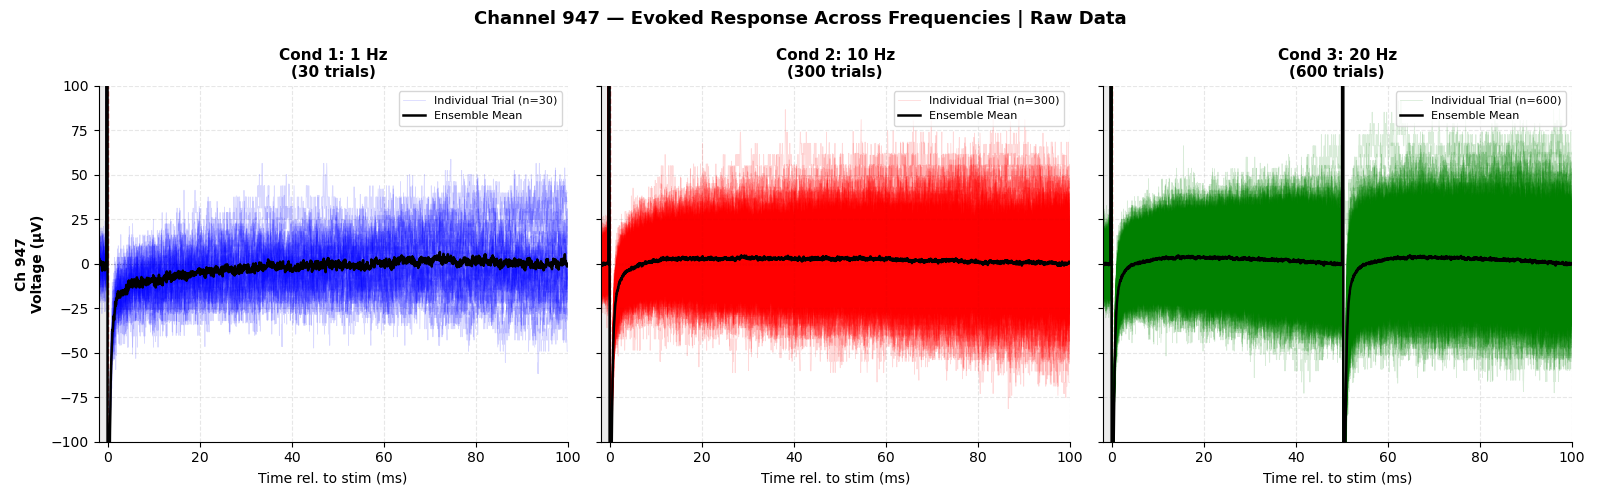

✓ Created and saved single-channel grid plot: C:\Users\dkhun\UCDavis\BenShalomLab\Analysis_pictures\Channel_947_EvokedResponses_09_26.png


In [7]:
from datetime import datetime
import os
import matplotlib.pyplot as plt
import numpy as np
# Use the boundaries generated by the unchanged conditions block above.
condition_labels = ['Cond 1: 1 Hz', 'Cond 2: 10 Hz', 'Cond 3: 20 Hz']
condition_colors = ['b', 'r', 'g']
 
CONDITIONS = [
    (label, max(0, float(t_start) - 1.0), float(t_end) + 1.0, color)
    for label, t_start, t_end, color in zip(
        condition_labels, block_starts, block_ends, condition_colors
    )
]

FREQ_LABELS = {
    'Cond 1': '1 Hz Block (30 pulses)',
    'Cond 2': '10 Hz Block (300 pulses)',
    'Cond 3': '20 Hz Block (600 pulses)',
}

# ── 1. USER PARAMETERS ───────────────────────────────────────
CHANNEL_ID = '947'  # Recording channel to analyze
PRE_MS = 2.0  # Pre-stimulus baseline window (ms)
POST_MS = 100.0  # Post-stimulus response window (ms)
USE_FILTERED = False  # Raw vs. filtered data flag
Y_MIN = -100  # y-axis limits (uV)
Y_MAX = 100

# Baseline correction window (relative to stimulation peak at t=0 ms)
BASELINE_START_MS = -4.5
BASELINE_END_MS = -0.5

# ── 2. DATA EXTRACTION AND SAMPLING ──────────────────────────
rec = recording_chunk if USE_FILTERED else recording1
fs = rec.get_sampling_frequency()
n_samp = rec.get_num_frames()

baseline_start_samps = int(BASELINE_START_MS / 1000 * fs)
baseline_end_samps = int(BASELINE_END_MS / 1000 * fs)

pre_samples = int(PRE_MS / 1000 * fs)
post_samples = int(POST_MS / 1000 * fs)
time_ms = np.arange(-pre_samples, post_samples) / fs * 1000

# Extract single channel trace and median-subtract
trace = rec.get_traces(channel_ids=[CHANNEL_ID], return_in_uV=True).squeeze()
trace = trace - np.median(trace)

peak_idxs = np.round(peak_times_s * fs).astype(int)

# ── 3. GENERATE 1x3 SUBPLOT GRID ─────────────────────────────
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(16, 5), sharex=True, sharey=True
)

mode_str = 'Bandpass Filtered' if USE_FILTERED else 'Raw Data'
fig.suptitle(
    f'Channel {CHANNEL_ID} — Evoked Response Across Frequencies | {mode_str}',
    fontsize=13,
    fontweight='bold',
    y=0.98,
)

for col_idx, (cond_name, t_start, t_end, cond_color) in enumerate(CONDITIONS):
    ax = axes[col_idx]

    # A. Filter stim timestamps belonging to current condition
    cond_mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
    idxs_in_block = peak_idxs[cond_mask]

    # B. Extract and baseline-correct trial snippets
    snippets = []
    for pk in idxs_in_block:
        block_start = pk + baseline_start_samps
        block_end = pk + baseline_end_samps

        snip_start = pk - pre_samples
        snip_end = pk + post_samples

        if block_start < 0 or snip_start < 0 or snip_end > n_samp:
            continue

        trial_baseline = trace[block_start:block_end].mean()
        snip = trace[snip_start:snip_end] - trial_baseline
        snippets.append(snip)

    snippets = np.array(snippets)
    n_trials = snippets.shape[0]

    if n_trials == 0:
        ax.text(
            0.5,
            0.5,
            'No Trials Detected',
            ha='center',
            va='center',
            transform=ax.transAxes,
        )
        continue

    # C. Ensemble average
    mean_trace = snippets.mean(axis=0)

    # D. Plot individual trials
    for i, snip in enumerate(snippets):
        line_label = f'Individual Trial (n={n_trials})' if i == 0 else None
        ax.plot(
            time_ms,
            snip,
            color=cond_color,
            alpha=0.15,
            lw=0.6,
            zorder=2,
            label=line_label,
        )

    # E. Plot ensemble mean
    ax.plot(
        time_ms,
        mean_trace,
        color='black',
        lw=1.8,
        zorder=3,
        label='Ensemble Mean',
    )

    # F. Reference lines & baseline shading
    ax.axvline(0, color='red', linestyle='--', lw=1.0, alpha=0.7, zorder=1)
    ax.axhline(0, color='gray', linestyle=':', lw=0.8, alpha=0.7, zorder=1)
    ax.axvspan(BASELINE_START_MS, BASELINE_END_MS, color='gray', alpha=0.15)

    # G. Axis labels, title, and limits
    ax.set_title(
        f'{cond_name}\n({n_trials} trials)', fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Time rel. to stim (ms)', fontsize=10)

    if col_idx == 0:
        ax.set_ylabel(
            f'Ch {CHANNEL_ID}\nVoltage (µV)', fontsize=10, fontweight='bold'
        )

    ax.set_xlim(-PRE_MS, POST_MS)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Legend only on the last panel to keep axes clean
    ax.legend(loc='upper right', frameon=True, facecolor='white', fontsize=8)

plt.tight_layout()

# ── 4. SAVE TO DIRECTORY WITH DATESTAMP ───────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)

date_str = datetime.now().strftime('%m_%y')
output_filename = f'Channel_{CHANNEL_ID}_EvokedResponses_{date_str}.png'
full_save_path = os.path.join(OUTPUT_DIR, output_filename)

plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Created and saved single-channel grid plot: {full_save_path}')

## Stimulus Response Plots for Many Channels
- conditions for 1hz block  
- Adjust 'CHANNELS'  
- Adjust pdf naming

In [ ]:
# LEFT CHANNELS

import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages

# ── PARAMETERS ────────────────────────────────────────────────
MAX_TRIALS_TO_PLOT = 30   # cap subplots per channel
NCOLS = 5                 # subplot grid width; rows are computed from this
COND_1HZ = CONDITIONS[0]  # 1Hz block

PRE_MS = 25
POST_MS = 150
Y_MIN= -100
Y_MAX= 100

cond_name, t_start, t_end, cond_color = COND_1HZ
cond_key = cond_name.split(':')[0].strip()
label = FREQ_LABELS.get(cond_key, cond_name)

# Row:
CHANNELS = [
    '616', '636', '760', '512', '520', '724', '716', '696', '688', '680', '592', '612', '620', '392', '756', '796', '740', '824', '820', '821',
    '848', '908', '876', '897', '892', '925', '996', '953', '968', '969', '449', '349', '477'
]

# Middle CHANNELS = [
#     '212', '929', '228', '921', '1012', '925', '480', '685', '544', '689', '548', '693', '252', '313', '100', '589', '72', '269', '56', '141',
#     '28', '497', '0', '185', '14', '213', '42', '229', '70', '125', '598', '97', '566', '81', '522', '51', '546', '79', '514', '107',
#     '622', '435', '654', '427', '650', '431', '698', '719', '922', '711', '930', '555', '926', '1015', '1010'
# ]

# Left CHANNELS = [
#     '980', '948', '988', '944', '828', '952', '820', '797', '608', '525', '432', '837', '464', '664', '380', '660', '752', '668', '376', '505',
#     '8', '748', '18', '448', '46', '456', '62', '68', '90', '76', '118', '48', '198', '2', '170', '30', '158', '222', '178', '74',
#     '658', '102', '690', '150', '542', '298', '814', '210', '446', '734', '1006', '1011', '586', '582', '554', '1014'
# ]

# ── DATA EXTRACTION ───────────────────────────────────────────
rec = recording_chunk if USE_FILTERED else recording1
fs = rec.get_sampling_frequency()
n_samp = rec.get_num_frames()

baseline_start_samps = int(BASELINE_START_MS / 1000 * fs)
baseline_end_samps = int(BASELINE_END_MS / 1000 * fs)
pre_samples = int(PRE_MS / 1000 * fs)
post_samples = int(POST_MS / 1000 * fs)
time_ms = np.arange(-pre_samples, post_samples) / fs * 1000

peak_idxs = np.round(peak_times_s * fs).astype(int)

available_ids = set(rec.get_channel_ids())
missing_channels = [ch for ch in CHANNELS if ch not in available_ids]
if missing_channels:
    raise ValueError(
        f"These left_channels are not present in rec (USE_FILTERED={USE_FILTERED}): "
        f"{missing_channels}. Update the left_channels list to valid ids, e.g. "
        f"{sorted(available_ids)[:10]} ..."
    )

all_traces = rec.get_traces(channel_ids=CHANNELS, return_in_uV=True)

# Stim timestamps belonging to the 1 Hz condition only
cond_mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
idxs_in_block = peak_idxs[cond_mask]

# ── SETUP PDF OUTPUT ──────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
date_str = datetime.now().strftime("%m_%d_%Y")
pdf_filename = f"Exp4_Middle_channels_1Hz_TrialSubplots_{date_str}.pdf"
pdf_path = os.path.join(OUTPUT_DIR, pdf_filename)
pdf = PdfPages(pdf_path)
print(f"Opened PDF for writing: {pdf_path}")

# ── ONE FIGURE (=ONE PDF PAGE) PER CHANNEL, TRIALS AS SUBPLOTS ─
for ch_pos, ch_id in enumerate(CHANNELS):
    trace = all_traces[:, ch_pos]
    trace = trace - np.median(trace)

    # Extract + baseline-correct snippets for this channel, 1Hz condition
    snippets = []
    for pk in idxs_in_block:
        block_start = pk + baseline_start_samps
        block_end = pk + baseline_end_samps
        snip_start = pk - pre_samples
        snip_end = pk + post_samples

        if block_start < 0 or snip_start < 0 or snip_end > n_samp:
            continue

        trial_baseline = trace[block_start:block_end].mean()
        snip = trace[snip_start:snip_end] - trial_baseline
        snippets.append(snip)

    snippets = np.array(snippets)
    n_trials = snippets.shape[0]
    n_to_plot = min(n_trials, MAX_TRIALS_TO_PLOT)
    ncols = min(NCOLS, max(n_to_plot, 1))
    nrows = int(np.ceil(n_to_plot / ncols)) if n_to_plot > 0 else 1

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(2.6 * ncols, 2.2 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        f'Ch {ch_id} — {label} — Individual Trials (n={n_trials})',
        fontsize=13, fontweight='bold', y=1.02,
    )

    if n_trials == 0:
        axes[0].text(0.5, 0.5, 'No Trials Detected', ha='center', va='center',
                      transform=axes[0].transAxes)
        for ax in axes[1:]:
            ax.axis('off')
    else:
        plot_idxs = np.linspace(0, n_trials - 1, n_to_plot).astype(int)

        for i, ax in enumerate(axes):
            if i >= n_to_plot:
                ax.axis('off')
                continue

            idx = plot_idxs[i]
            ax.plot(time_ms, snippets[idx], color=cond_color, lw=0.7)
            ax.axvline(0, color='red', linestyle='--', lw=0.8, alpha=0.9)
            ax.axhline(0, color='black', linestyle=':', lw=0.8, alpha=0.9, zorder=5)
            ax.axvspan(BASELINE_START_MS, BASELINE_END_MS, color='gray', alpha=0.12)
            ax.set_title(f'Trial {idx + 1}', fontsize=8)
            ax.set_xlim(-PRE_MS, POST_MS)
            ax.set_ylim(Y_MIN, Y_MAX) # 100 µvolts
            ax.tick_params(labelsize=6)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    fig.supxlabel('Time rel. to stim (ms)', fontsize=10)
    fig.supylabel('Voltage (µV)', fontsize=10)

    plt.tight_layout()
    pdf.savefig(fig, dpi=300, bbox_inches='tight')
    #plt.show()
    plt.close(fig)

    print(f"✓ Appended page for Ch {ch_id}")

pdf.close()
print(f"✓ Saved PDF: {pdf_path}")


NameError: name 'CHANNELS' is not defined

## Peak Amplitude vs Distance from Stimulation Site

In [ ]:
import os
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# ── PARAMETERS ────────────────────────────────────────────────
STIM_CHANNEL_ID = '824'  # Define your stimulation channel ID
COND_1HZ = CONDITIONS[0]  # 1Hz block

PRE_MS = 10
POST_MS = 10
Y_MIN = 0
Y_MAX = 4000  # Max amplitude bound in µV

cond_name, t_start, t_end, cond_color = COND_1HZ
cond_key = cond_name.split(':')[0].strip()
label = FREQ_LABELS.get(cond_key, cond_name)

#Row Channels:
# CHANNELS = [
#     '616', '636', '760', '512', '520', '724', '716', '696', '688', '680', '592', '612', '620', '392', '756', '796', '740', '824', '820', '821',
#     '848', '908', '876', '897', '892', '925', '996', '953', '968', '969', '449', '349', '477'
# ]

# Left Col Channels:
# CHANNELS = [
#     '980', '948', '988', '944', '828', '952', '820', '797', '608', '525', '432', '837', '464', '664', '380', '660', '752', '668', '376', '505',
#     '8', '748', '18', '448', '46', '456', '62', '68', '90', '76', '118', '48', '198', '2', '170', '30', '158', '222', '178', '74',
#     '658', '102', '690', '150', '542', '298', '814', '210', '446', '734', '1006', '1011', '586', '582', '554', '1014'
# ]

# Middle Col Channels:
CHANNELS = [
    '212', '929', '228', '921', '1012', '925', '480', '685', '544', '689', '548', '693', '252', '313', '100', '589', '72', '269', '56', '141',
    '28', '497', '0', '185', '14', '213', '42', '229', '70', '125', '598', '97', '566', '81', '522', '51', '546', '79', '514', '107',
    '622', '435', '654', '427', '650', '431', '698', '719', '922', '711', '930', '555', '926', '1015', '1010'
]

# ── DATA & GEOMETRY EXTRACTION ────────────────────────────────
rec = recording_chunk if USE_FILTERED else recording1
fs = rec.get_sampling_frequency()
n_samp = rec.get_num_frames()

# Spatial distance calculations
all_channel_ids = list(rec.get_channel_ids())
all_locations = rec.get_channel_locations()

if STIM_CHANNEL_ID not in all_channel_ids:
  raise ValueError(f'Stimulation channel {STIM_CHANNEL_ID} not found in rec.')

stim_idx = all_channel_ids.index(STIM_CHANNEL_ID)
stim_coord = all_locations[stim_idx]

# Pre-calculate distances for target channels
channel_distances = {}
for ch in CHANNELS:
  if ch in all_channel_ids:
    ch_idx = all_channel_ids.index(ch)
    dist = np.linalg.norm(all_locations[ch_idx] - stim_coord)
    channel_distances[ch] = dist

baseline_start_samps = int(BASELINE_START_MS / 1000 * fs)
baseline_end_samps = int(BASELINE_END_MS / 1000 * fs)
pre_samples = int(PRE_MS / 1000 * fs)
post_samples = int(POST_MS / 1000 * fs)

peak_idxs = np.round(peak_times_s * fs).astype(int)
cond_mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
idxs_in_block = peak_idxs[cond_mask]

all_traces = rec.get_traces(channel_ids=CHANNELS, return_in_uV=True)

# ── COMPUTE MAX AMPLITUDE PER CHANNEL ────────────────────────
plot_distances = []
plot_mean_max_amps = []
plot_std_max_amps = []
all_trial_distances = []
all_trial_max_amps = []

for ch_pos, ch_id in enumerate(CHANNELS):
  trace = all_traces[:, ch_pos]
  trace = trace - np.median(trace)
  dist = channel_distances[ch_id]

  trial_max_amps = []
  for pk in idxs_in_block:
    block_start = pk + baseline_start_samps
    block_end = pk + baseline_end_samps
    snip_start = pk - pre_samples
    snip_end = pk + post_samples

    if block_start < 0 or snip_start < 0 or snip_end > n_samp:
      continue

    trial_baseline = trace[block_start:block_end].mean()
    snip = trace[snip_start:snip_end] - trial_baseline

    # Extract peak absolute amplitude in window
    max_amp = np.max(np.abs(snip))
    trial_max_amps.append(max_amp)

  if len(trial_max_amps) > 0:
    plot_distances.append(dist)
    plot_mean_max_amps.append(np.mean(trial_max_amps))
    plot_std_max_amps.append(np.std(trial_max_amps))

    # Collect individual trial points for scatter plot
    all_trial_distances.extend([dist] * len(trial_max_amps))
    all_trial_max_amps.extend(trial_max_amps)

# ── PLOTTING: MAX AMPLITUDE VS DISTANCE ───────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Plot raw trial scatter points
ax.scatter(
    all_trial_distances,
    all_trial_max_amps,
    color=cond_color,
    alpha=0.3,
    s=15,
    label='Individual Trials',
)
temp = len(all_trial_max_amps)
# Plot mean ± SD per channel
ax.errorbar(
    plot_distances,
    plot_mean_max_amps,
    yerr=plot_std_max_amps,
    fmt='o',
    color='black',
    ecolor='black',
    elinewidth=1.5,
    capsize=3,
    label='Mean ± SD',
)

ax.set_title(
    f'Artifact Amplitude vs. Distance from Stim Site (Ch {STIM_CHANNEL_ID}) — {label}',
    fontsize=12, fontweight='bold',)

ax.set_xlabel('Distance from Stimulation Electrode (μm)', fontsize=10)
ax.set_ylabel('Max Absolute Amplitude (μV)', fontsize=10)
ax.set_ylim(Y_MIN, Y_MAX)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')


plt.tight_layout()
plt.text(0.95, 0.02, f'n_channels={len(plot_distances)}\nn_trials={len(all_trial_max_amps)}',
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom', color='gray')

# ── SAVE TO PDF ───────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
date_str = datetime.now().strftime('%m_%d_%Y')
pdf_filename = f'Exp4_MaxAmp_vs_Distance_Middle_Column_{date_str}.pdf'
pdf_path = os.path.join(OUTPUT_DIR, pdf_filename)

with PdfPages(pdf_path) as pdf:
  pdf.savefig(fig, dpi=300, bbox_inches='tight')

plt.close(fig)
print(f'✓ Saved Max Amplitude vs. Distance plot to: {pdf_path}')

1650
✓ Saved Max Amplitude vs. Distance plot to: C:\Users\dkhun\UCDavis\BenShalomLab\Analysis_pictures\Exp4_MaxAmp_vs_Distance_Middle_Column_09_15_2026.pdf


['1000', '72', '16', '13', '197', '622']
Opened PDF for writing: /Users/jpxmaestas/UCDavis/BenShalomLab/Analysis_pictures/MiddleChannels_1Hz_TrialSubplots_09_11_2026.pdf


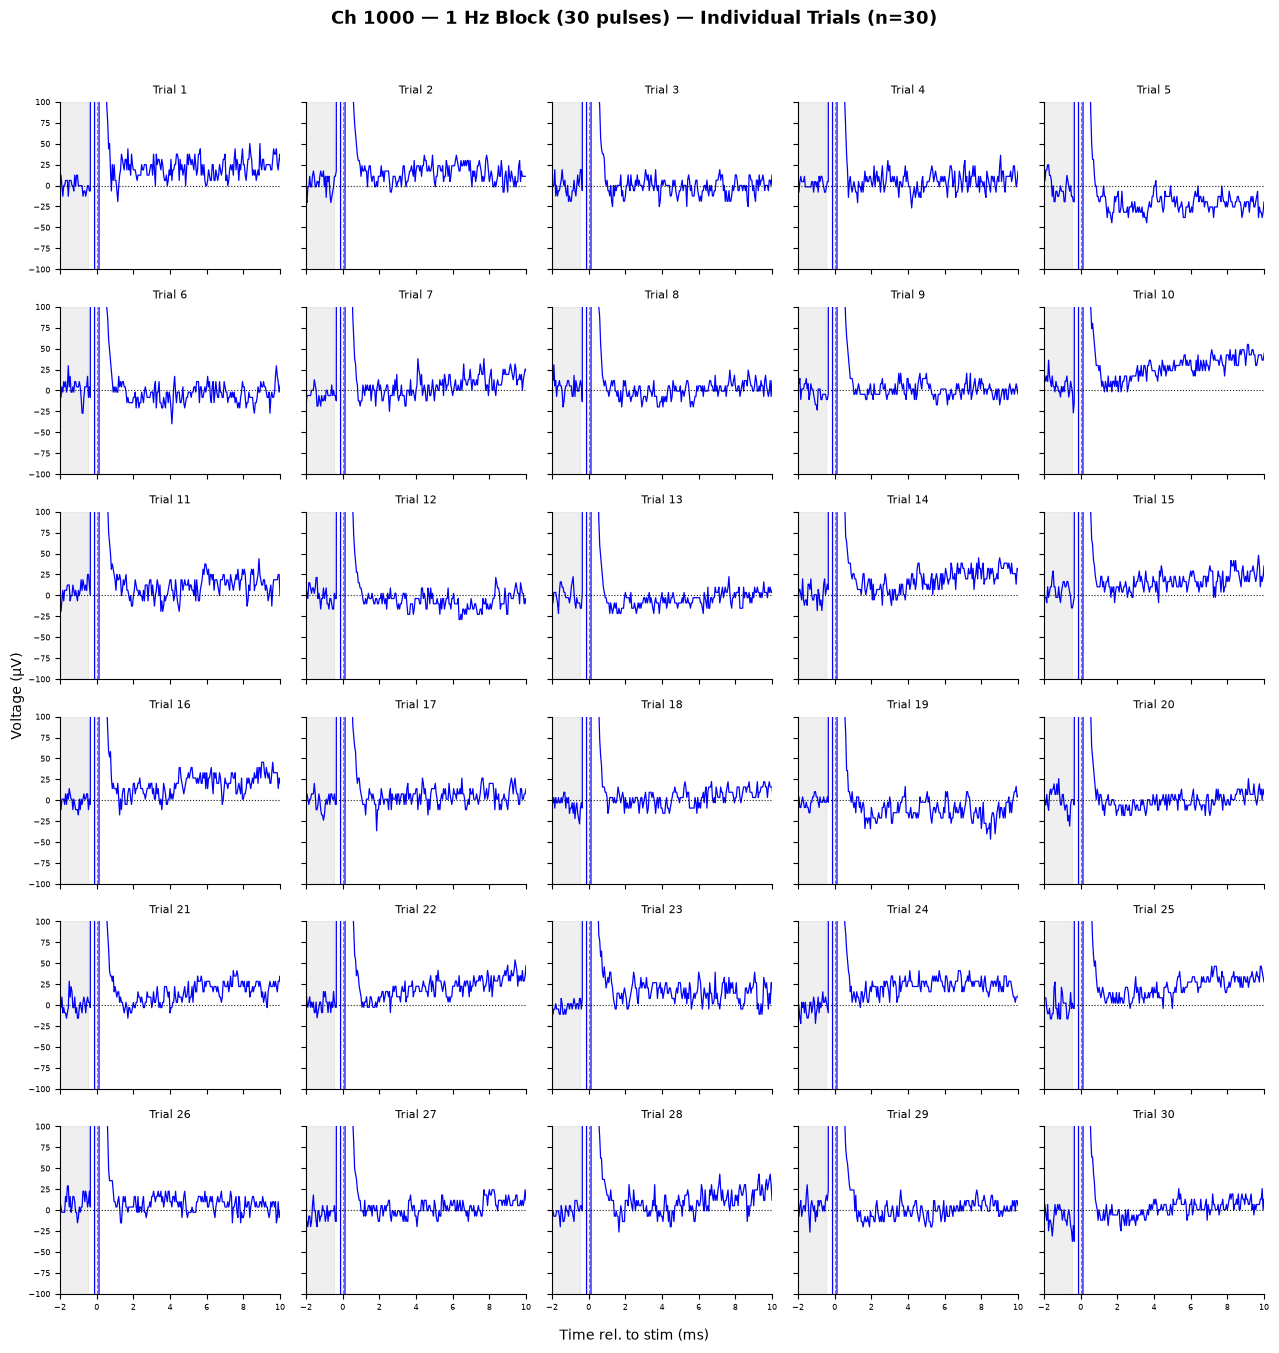

✓ Appended page for Ch 1000


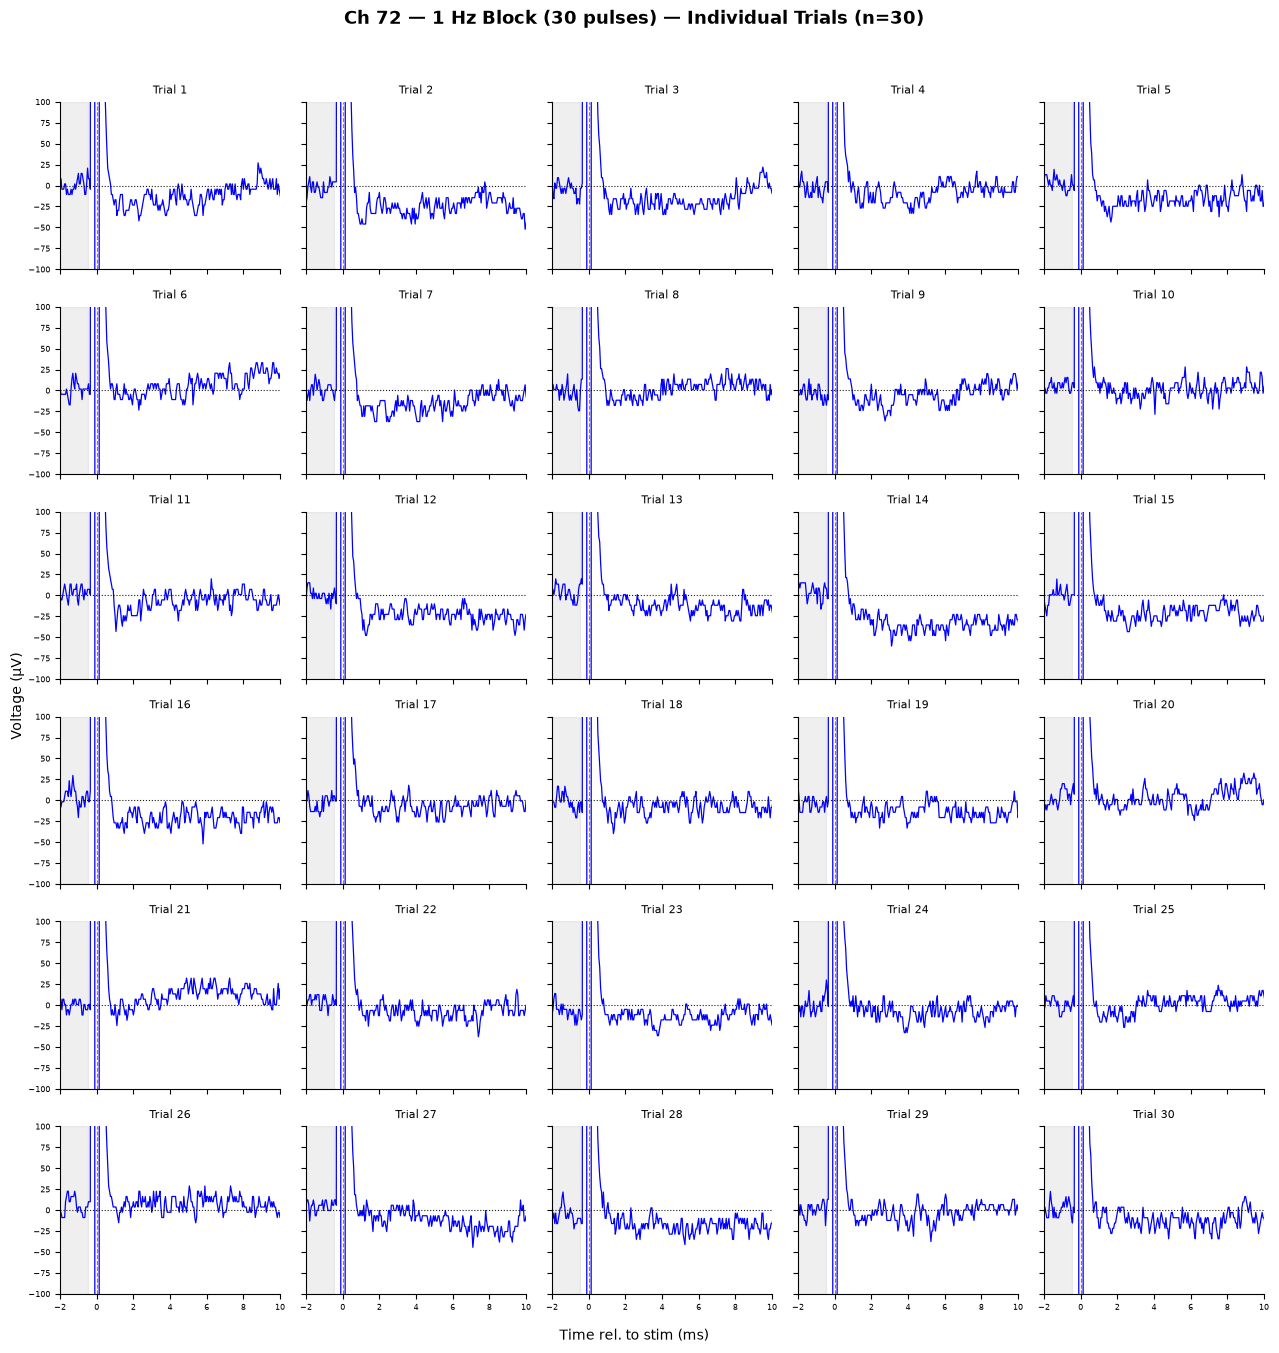

✓ Appended page for Ch 72


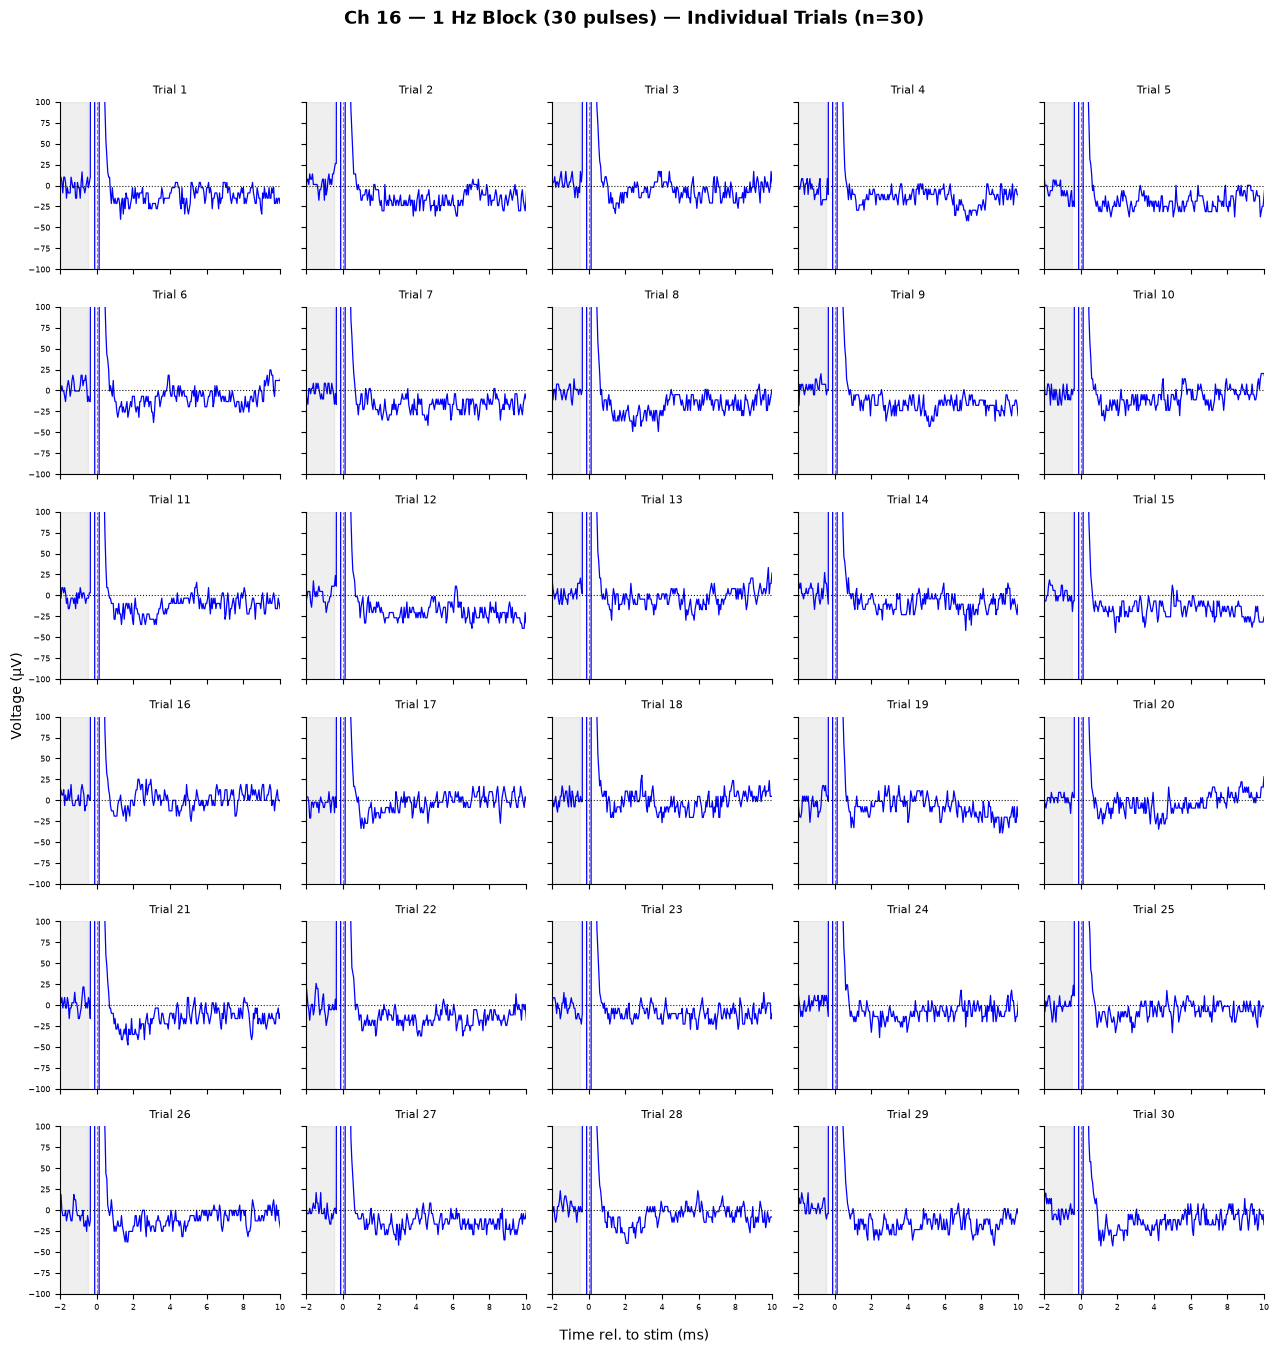

✓ Appended page for Ch 16


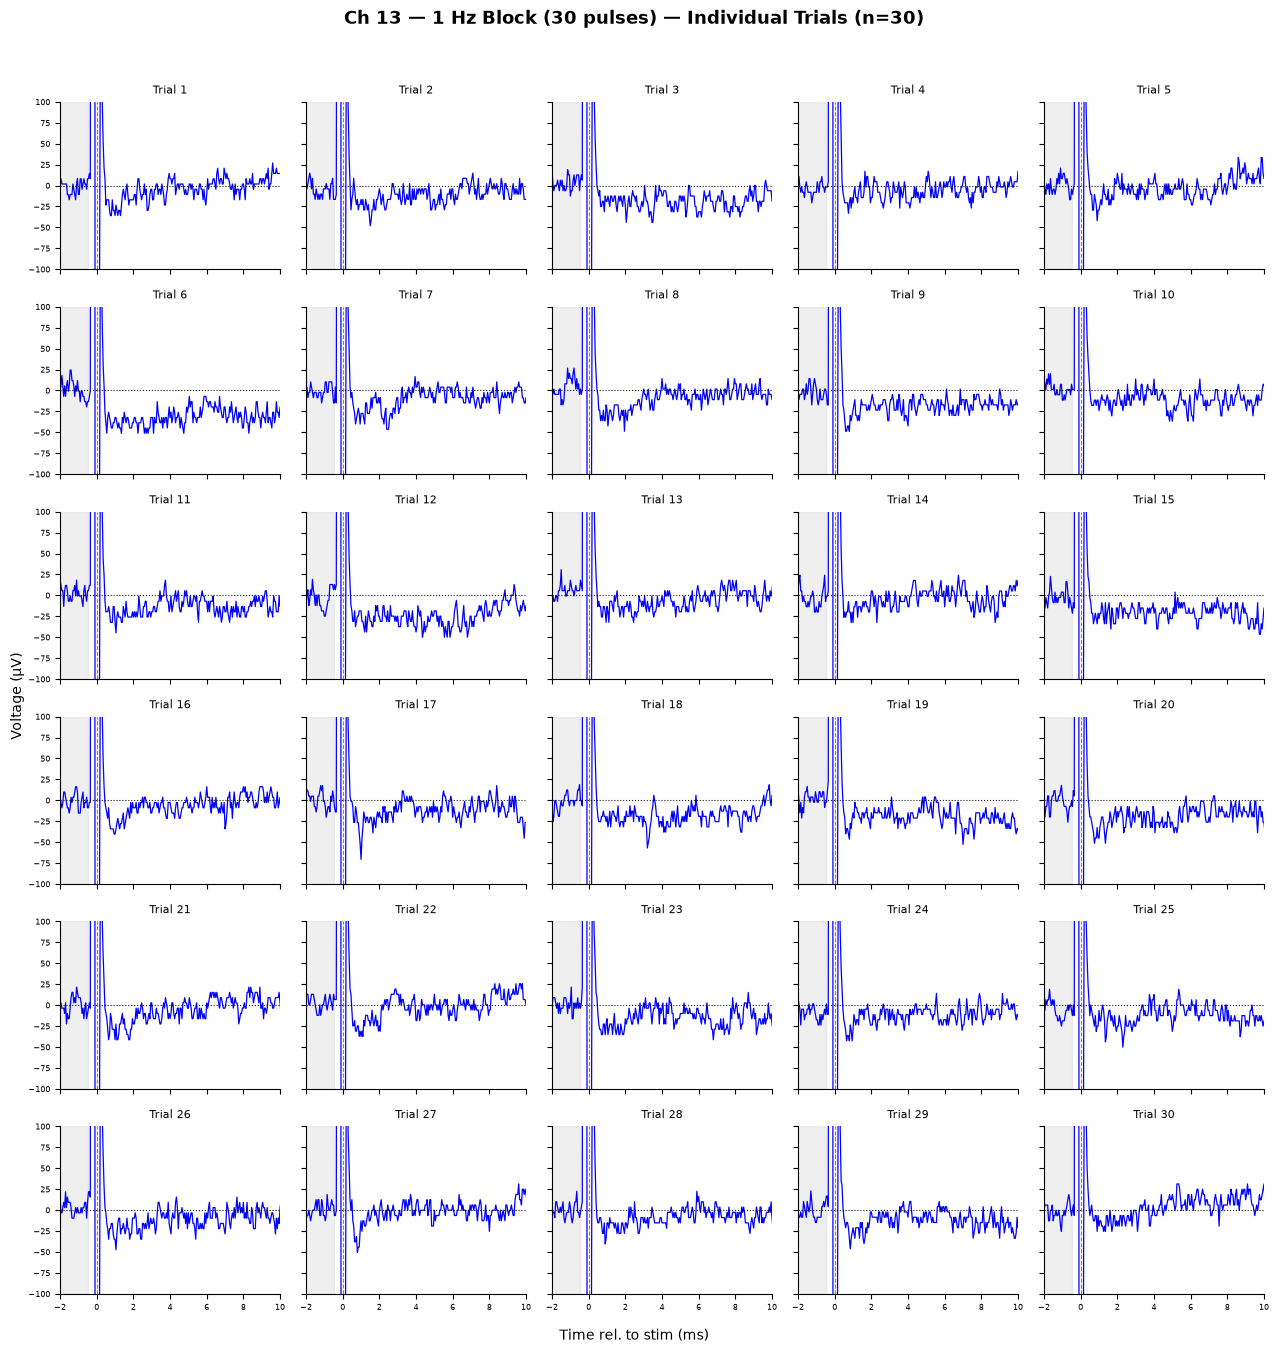

✓ Appended page for Ch 13


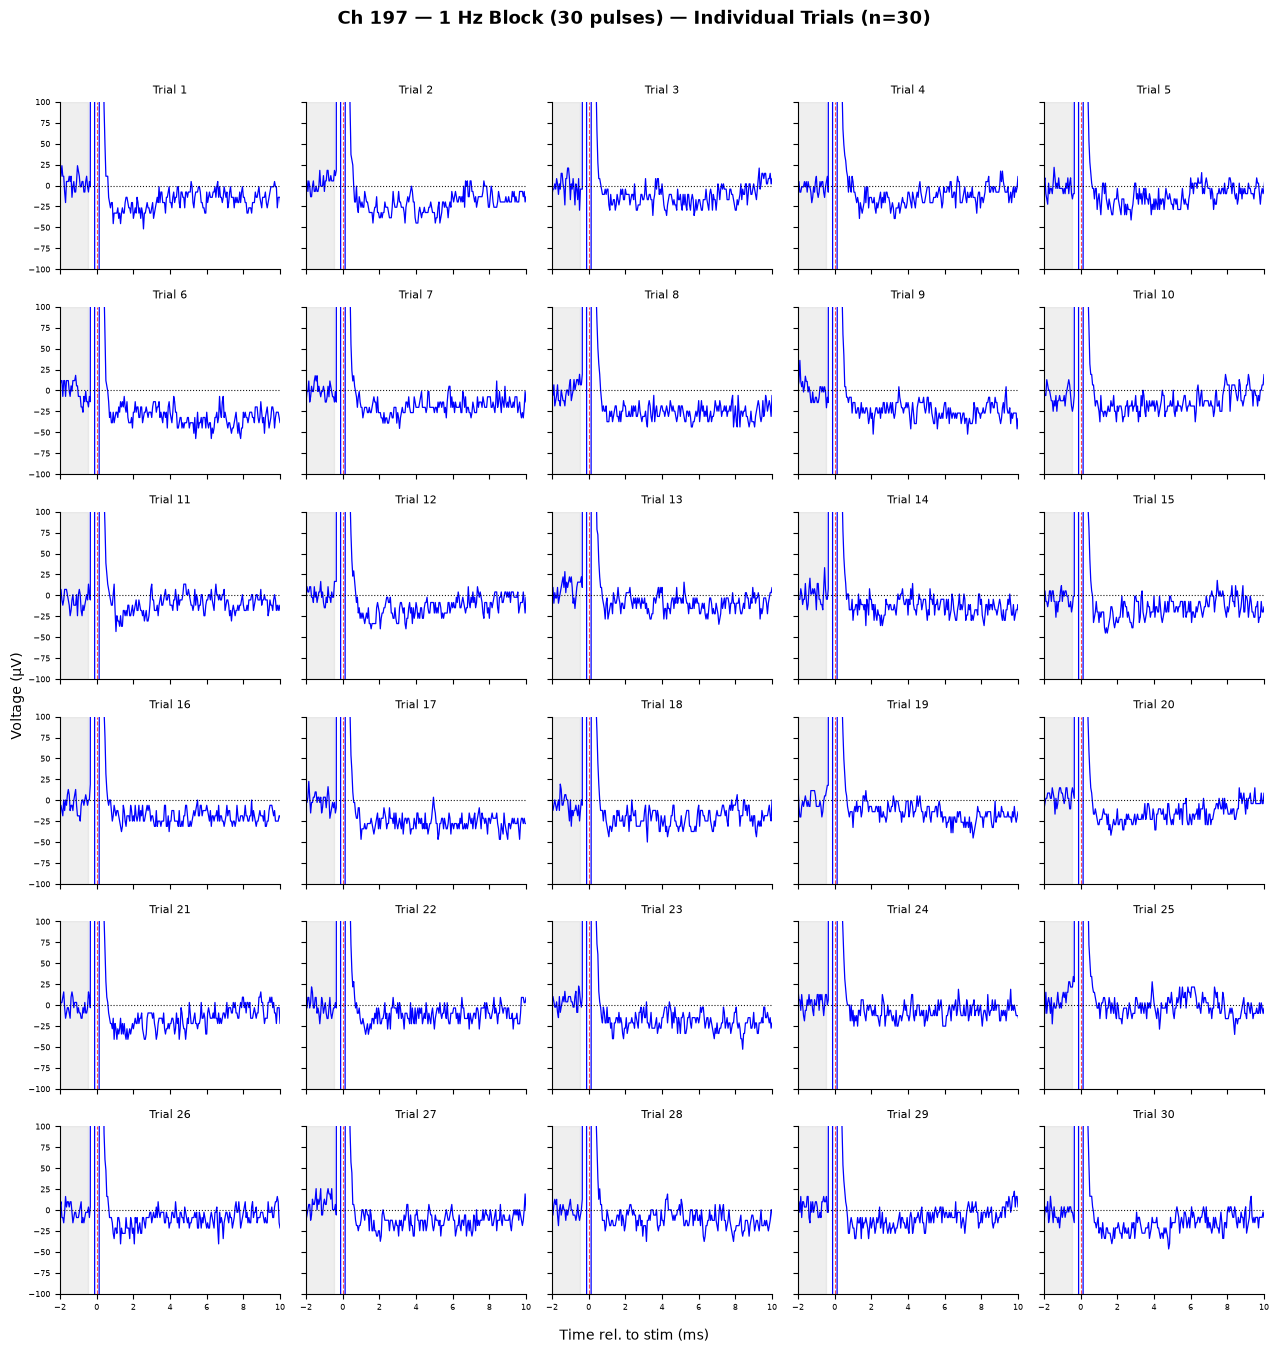

✓ Appended page for Ch 197


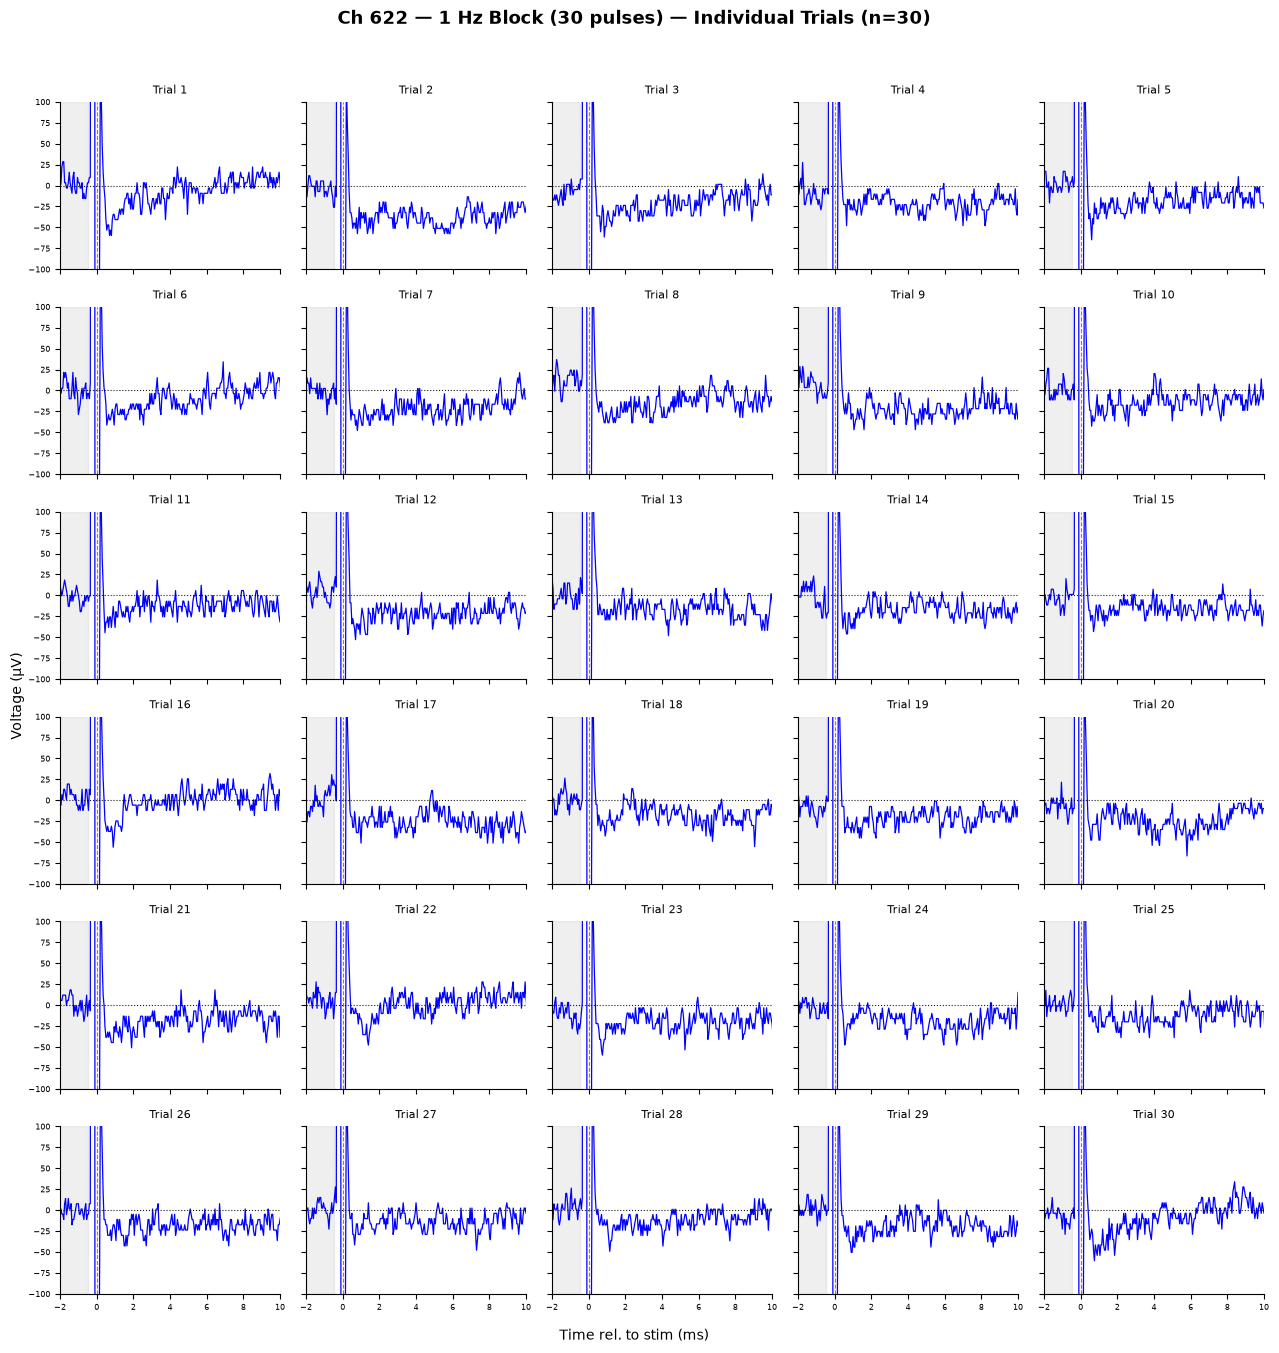

✓ Appended page for Ch 622
✓ Saved PDF: /Users/jpxmaestas/UCDavis/BenShalomLab/Analysis_pictures/MiddleChannels_1Hz_TrialSubplots_09_11_2026.pdf


In [ ]:
print(middle_channels)
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages

# ── PARAMETERS ────────────────────────────────────────────────
MAX_TRIALS_TO_PLOT = 30   # cap subplots per channel
NCOLS = 5                 # subplot grid width; rows are computed from this
COND_1HZ = CONDITIONS[0]  # 1Hz block

cond_name, t_start, t_end, cond_color = COND_1HZ
cond_key = cond_name.split(':')[0].strip()
label = FREQ_LABELS.get(cond_key, cond_name)

# ── DATA EXTRACTION ───────────────────────────────────────────
rec = recording_chunk if USE_FILTERED else recording1
fs = rec.get_sampling_frequency()
n_samp = rec.get_num_frames()

baseline_start_samps = int(BASELINE_START_MS / 1000 * fs)
baseline_end_samps = int(BASELINE_END_MS / 1000 * fs)
pre_samples = int(PRE_MS / 1000 * fs)
post_samples = int(POST_MS / 1000 * fs)
time_ms = np.arange(-pre_samples, post_samples) / fs * 1000

peak_idxs = np.round(peak_times_s * fs).astype(int)

available_ids = set(rec.get_channel_ids())
missing_channels = [ch for ch in middle_channels if ch not in available_ids]
if missing_channels:
    raise ValueError(
        f"These middle_channels are not present in rec (USE_FILTERED={USE_FILTERED}): "
        f"{missing_channels}. Update the middle_channels list to valid ids, e.g. "
        f"{sorted(available_ids)[:10]} ..."
    )

all_traces = rec.get_traces(channel_ids=middle_channels, return_in_uV=True)

# Stim timestamps belonging to the 1 Hz condition only
cond_mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
idxs_in_block = peak_idxs[cond_mask]

# ── SETUP PDF OUTPUT ──────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
date_str = datetime.now().strftime("%m_%d_%Y")
pdf_filename = f"MiddleChannels_1Hz_TrialSubplots_{date_str}.pdf"
pdf_path = os.path.join(OUTPUT_DIR, pdf_filename)
pdf = PdfPages(pdf_path)
print(f"Opened PDF for writing: {pdf_path}")

# ── ONE FIGURE (=ONE PDF PAGE) PER CHANNEL, TRIALS AS SUBPLOTS ─
for ch_pos, ch_id in enumerate(middle_channels):
    trace = all_traces[:, ch_pos]
    trace = trace - np.median(trace)

    # Extract + baseline-correct snippets for this channel, 1Hz condition
    snippets = []
    for pk in idxs_in_block:
        block_start = pk + baseline_start_samps
        block_end = pk + baseline_end_samps
        snip_start = pk - pre_samples
        snip_end = pk + post_samples

        if block_start < 0 or snip_start < 0 or snip_end > n_samp:
            continue

        trial_baseline = trace[block_start:block_end].mean()
        snip = trace[snip_start:snip_end] - trial_baseline
        snippets.append(snip)

    snippets = np.array(snippets)
    n_trials = snippets.shape[0]
    n_to_plot = min(n_trials, MAX_TRIALS_TO_PLOT)
    ncols = min(NCOLS, max(n_to_plot, 1))
    nrows = int(np.ceil(n_to_plot / ncols)) if n_to_plot > 0 else 1

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(2.6 * ncols, 2.2 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        f'Ch {ch_id} — {label} — Individual Trials (n={n_trials})',
        fontsize=13, fontweight='bold', y=1.02,
    )

    if n_trials == 0:
        axes[0].text(0.5, 0.5, 'No Trials Detected', ha='center', va='center',
                      transform=axes[0].transAxes)
        for ax in axes[1:]:
            ax.axis('off')
    else:
        plot_idxs = np.linspace(0, n_trials - 1, n_to_plot).astype(int)

        for i, ax in enumerate(axes):
            if i >= n_to_plot:
                ax.axis('off')
                continue

            idx = plot_idxs[i]
            ax.plot(time_ms, snippets[idx], color=cond_color, lw=0.9)
            ax.axvline(0, color='red', linestyle='--', lw=0.8, alpha=0.7)
            ax.axhline(0, color='black', linestyle=':', lw=0.8, alpha=0.9, zorder=5)
            ax.axvspan(BASELINE_START_MS, BASELINE_END_MS, color='gray', alpha=0.12)
            ax.set_title(f'Trial {idx + 1}', fontsize=8)
            ax.set_xlim(-PRE_MS, 10)
            ax.set_ylim(Y_MIN, Y_MAX) # 100 µvolts
            ax.tick_params(labelsize=6)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    fig.supxlabel('Time rel. to stim (ms)', fontsize=10)
    fig.supylabel('Voltage (µV)', fontsize=10)

    plt.tight_layout()
    pdf.savefig(fig, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f"✓ Appended page for Ch {ch_id}")

pdf.close()
print(f"✓ Saved PDF: {pdf_path}")


## end


['821', '148', '532', '296', '258', '766']
Opened PDF for writing: /Users/jpxmaestas/UCDavis/BenShalomLab/Analysis_pictures/EndChannels_1Hz_TrialSubplots_09_11_2026.pdf


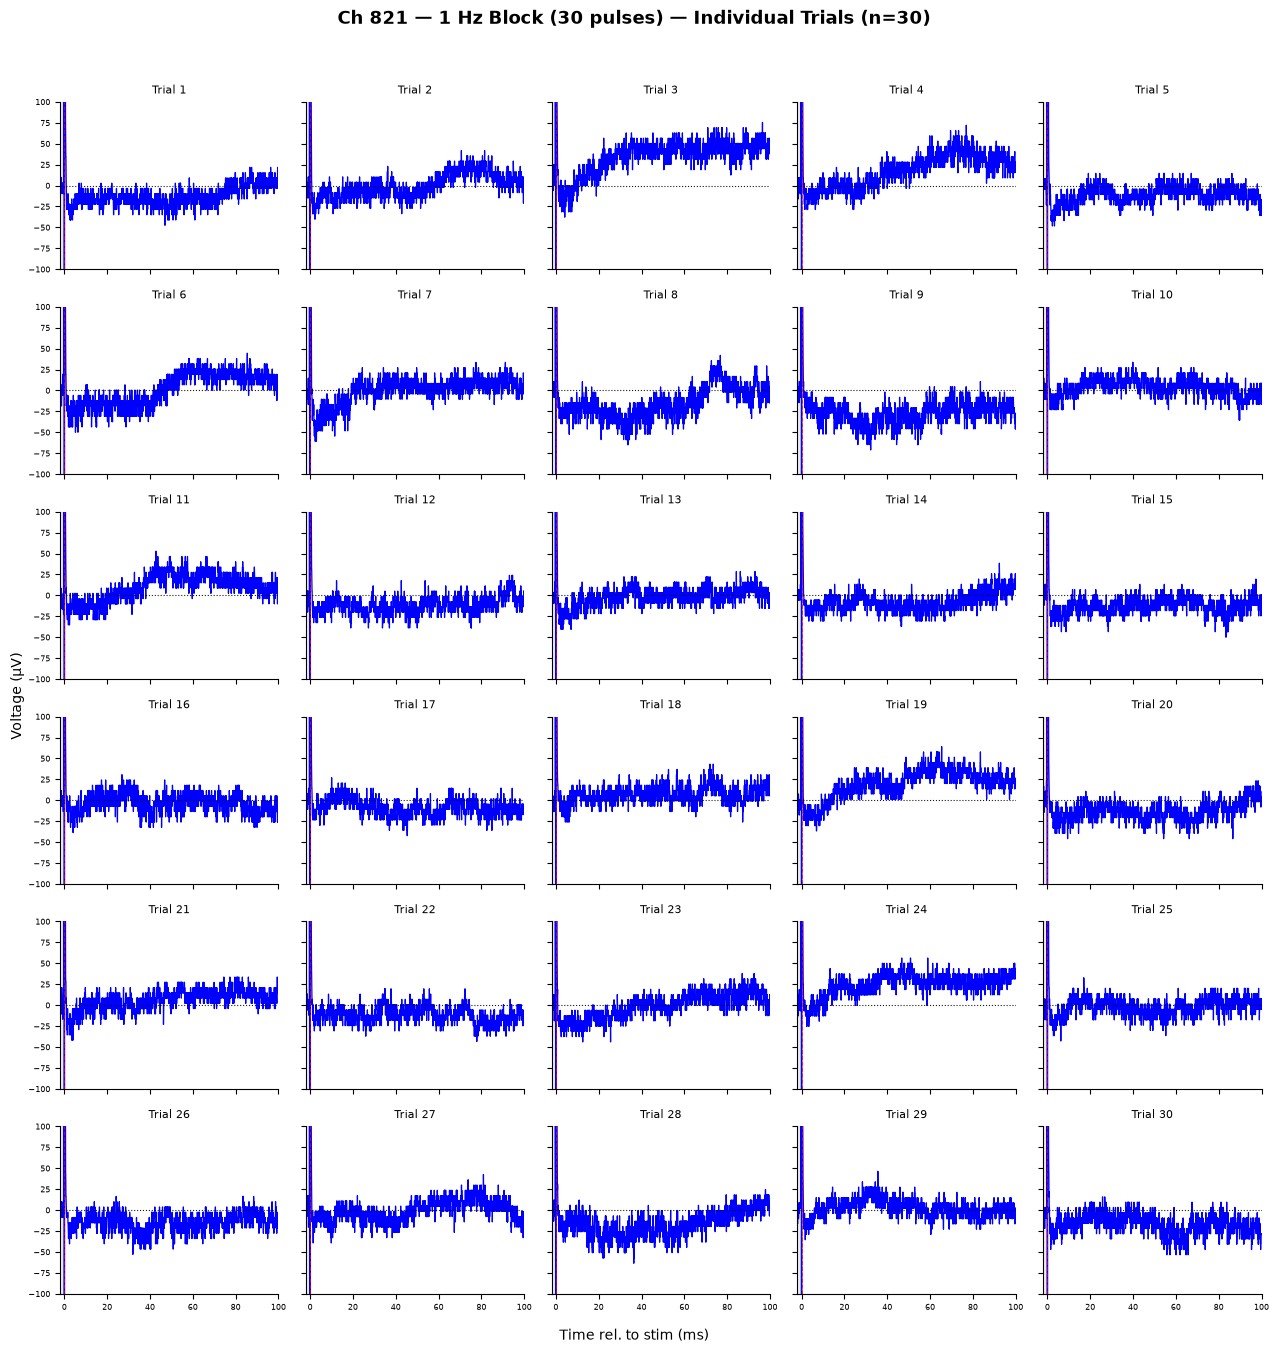

✓ Appended page for Ch 821


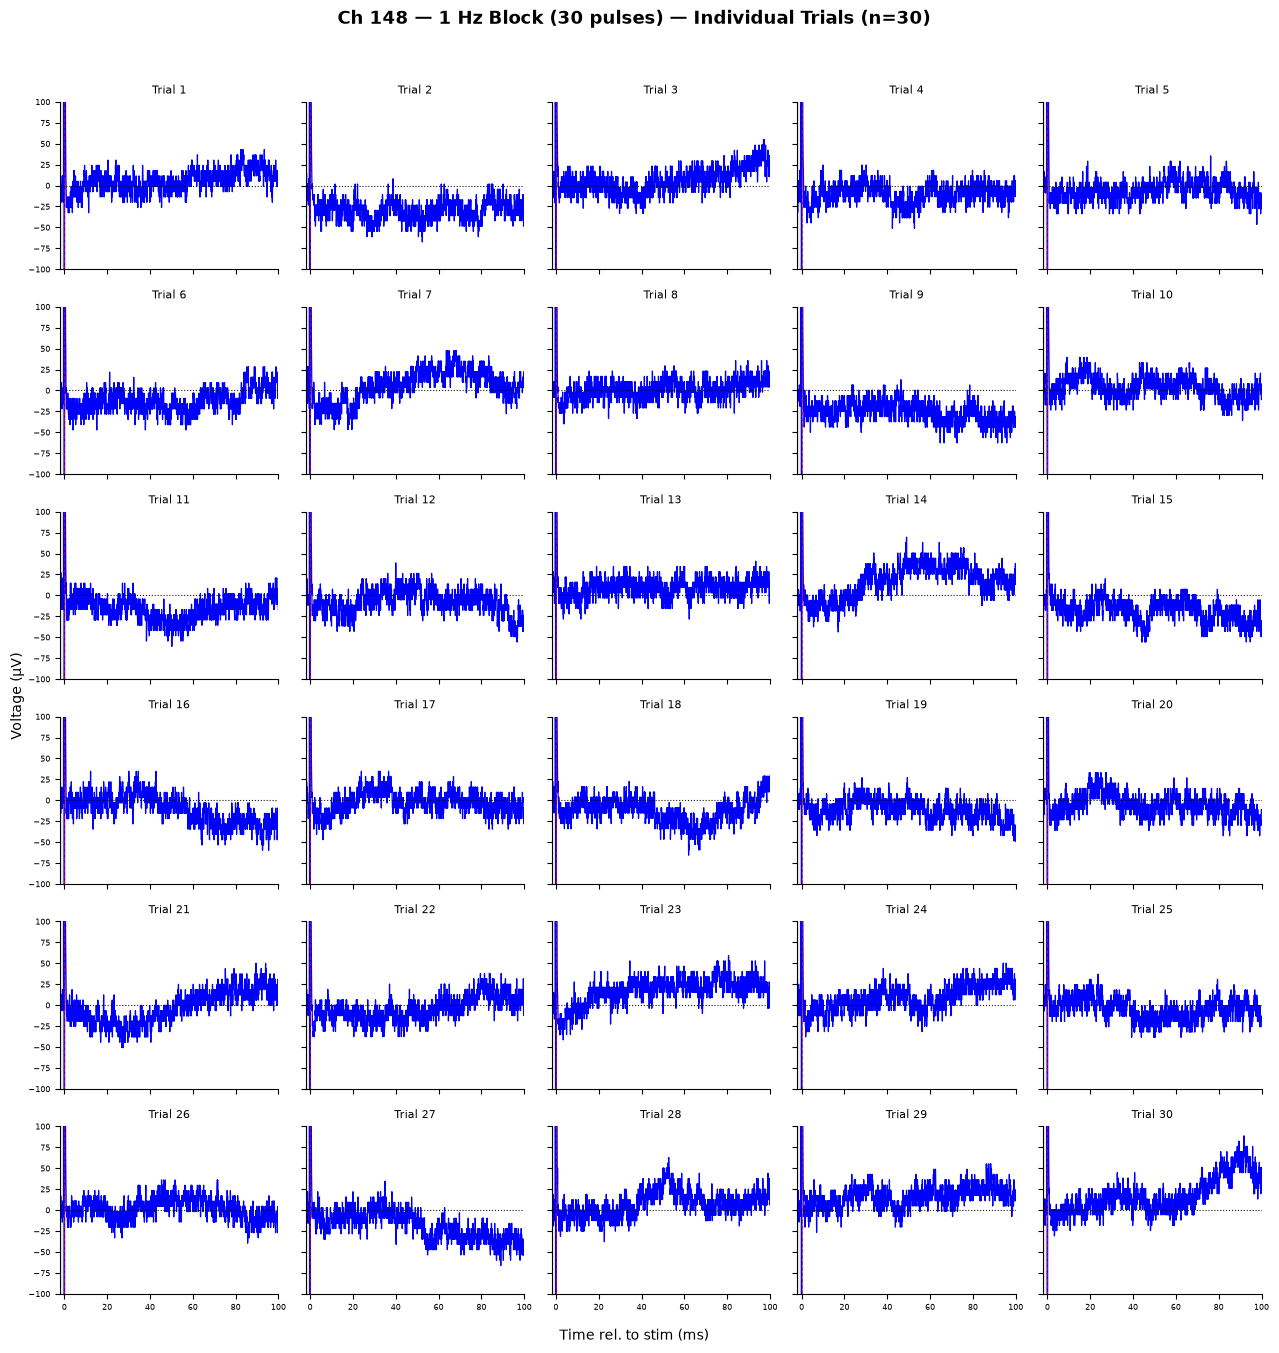

✓ Appended page for Ch 148


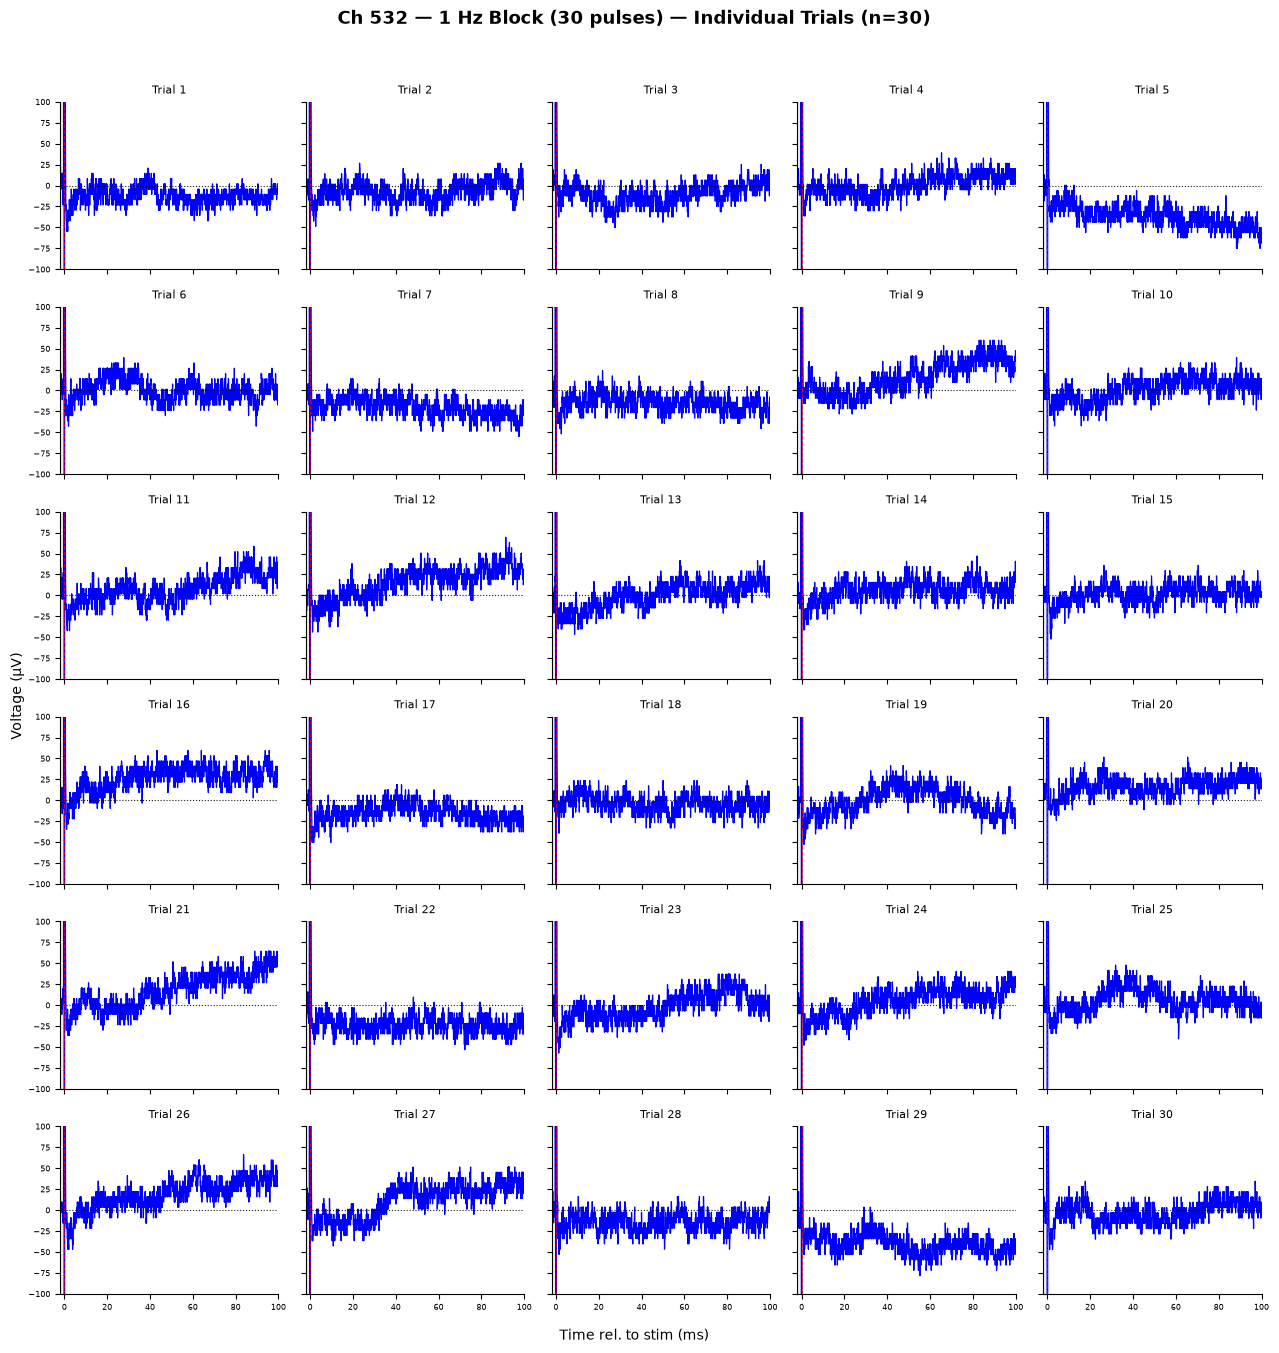

✓ Appended page for Ch 532


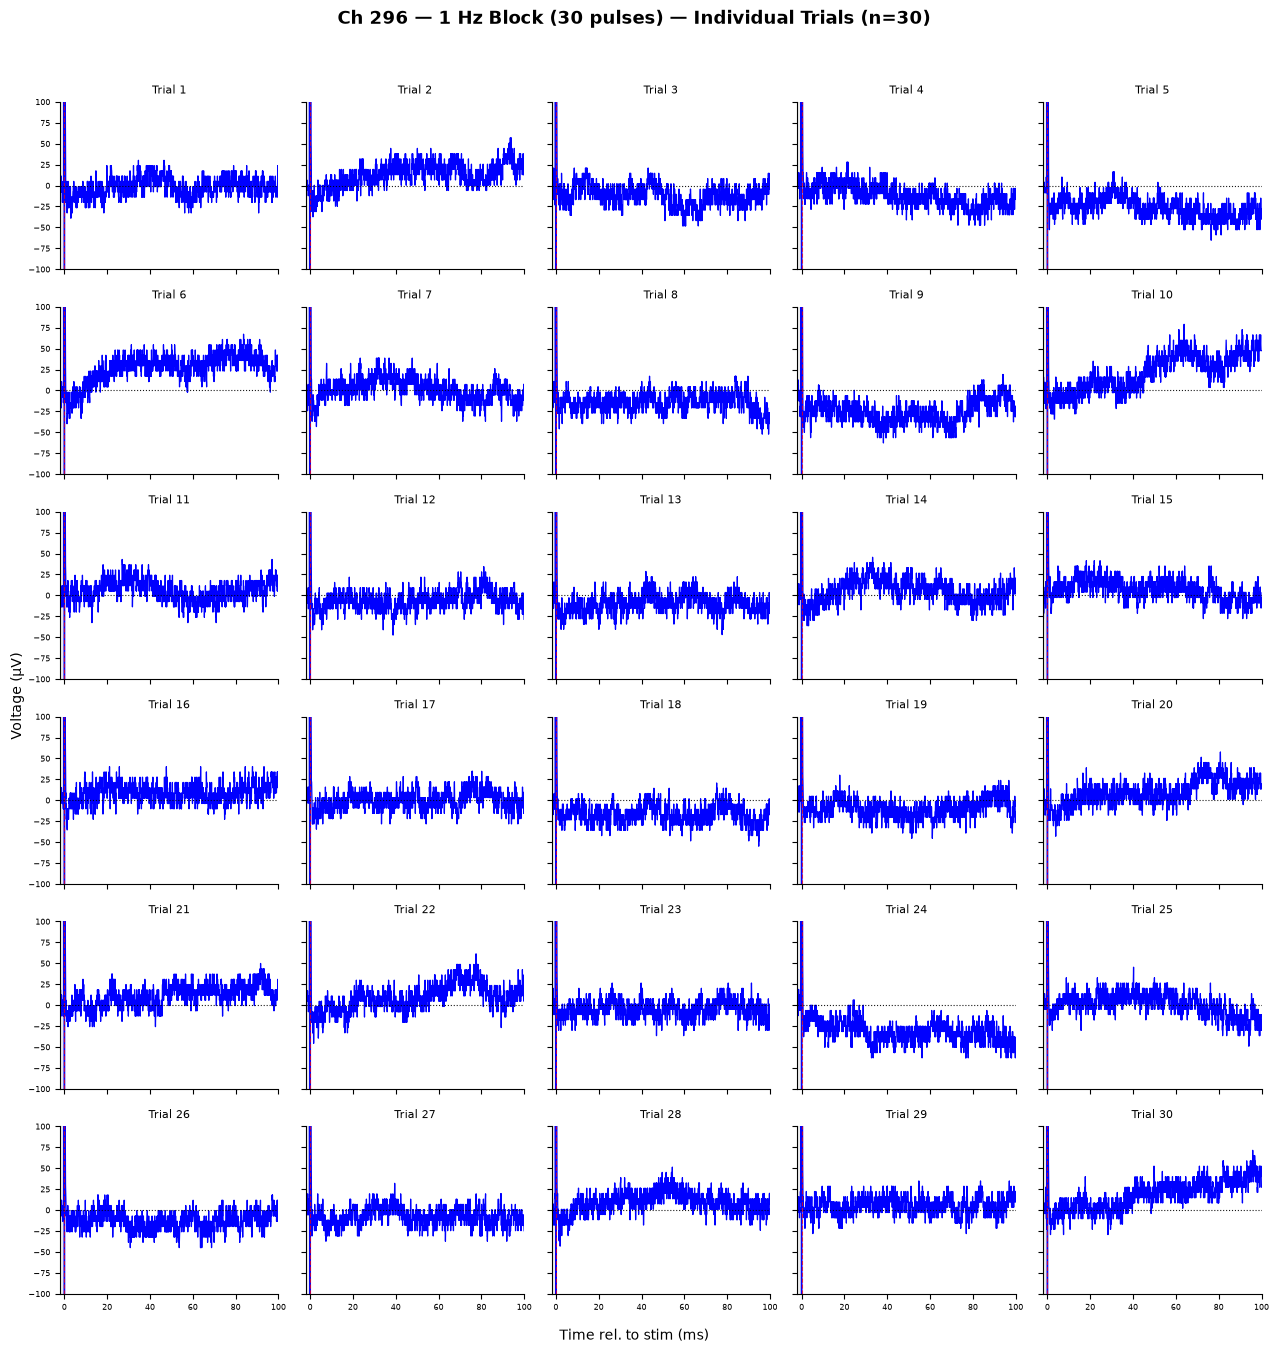

✓ Appended page for Ch 296


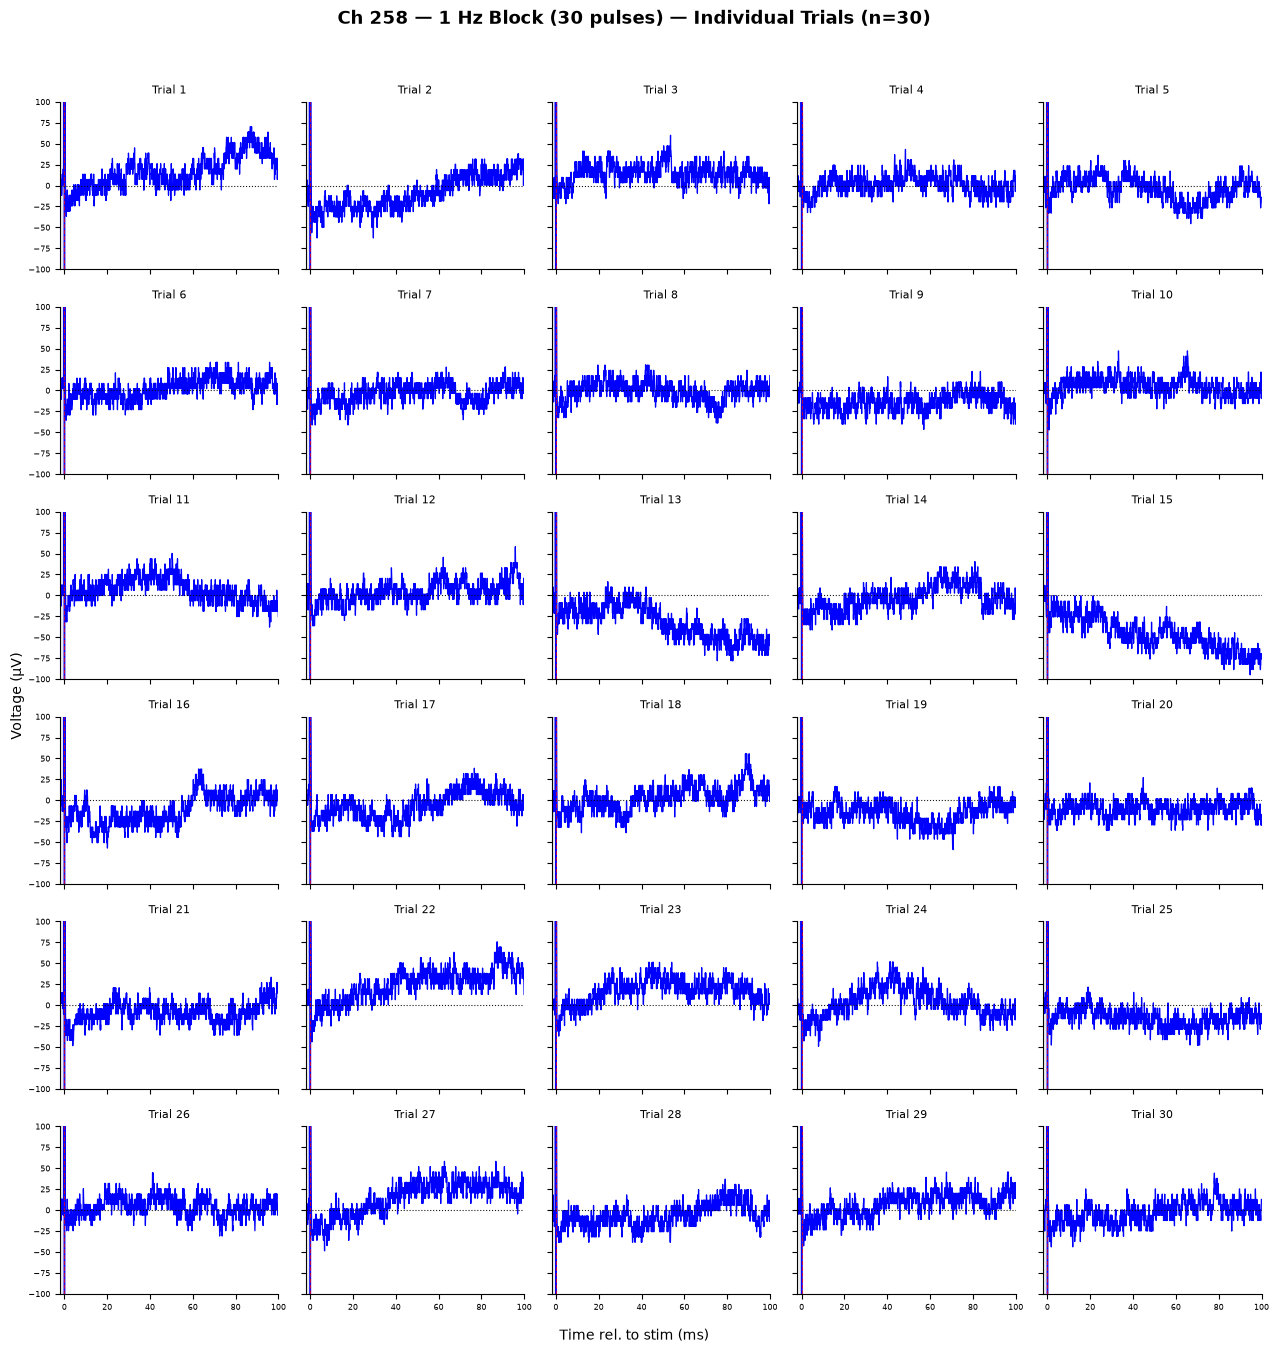

✓ Appended page for Ch 258


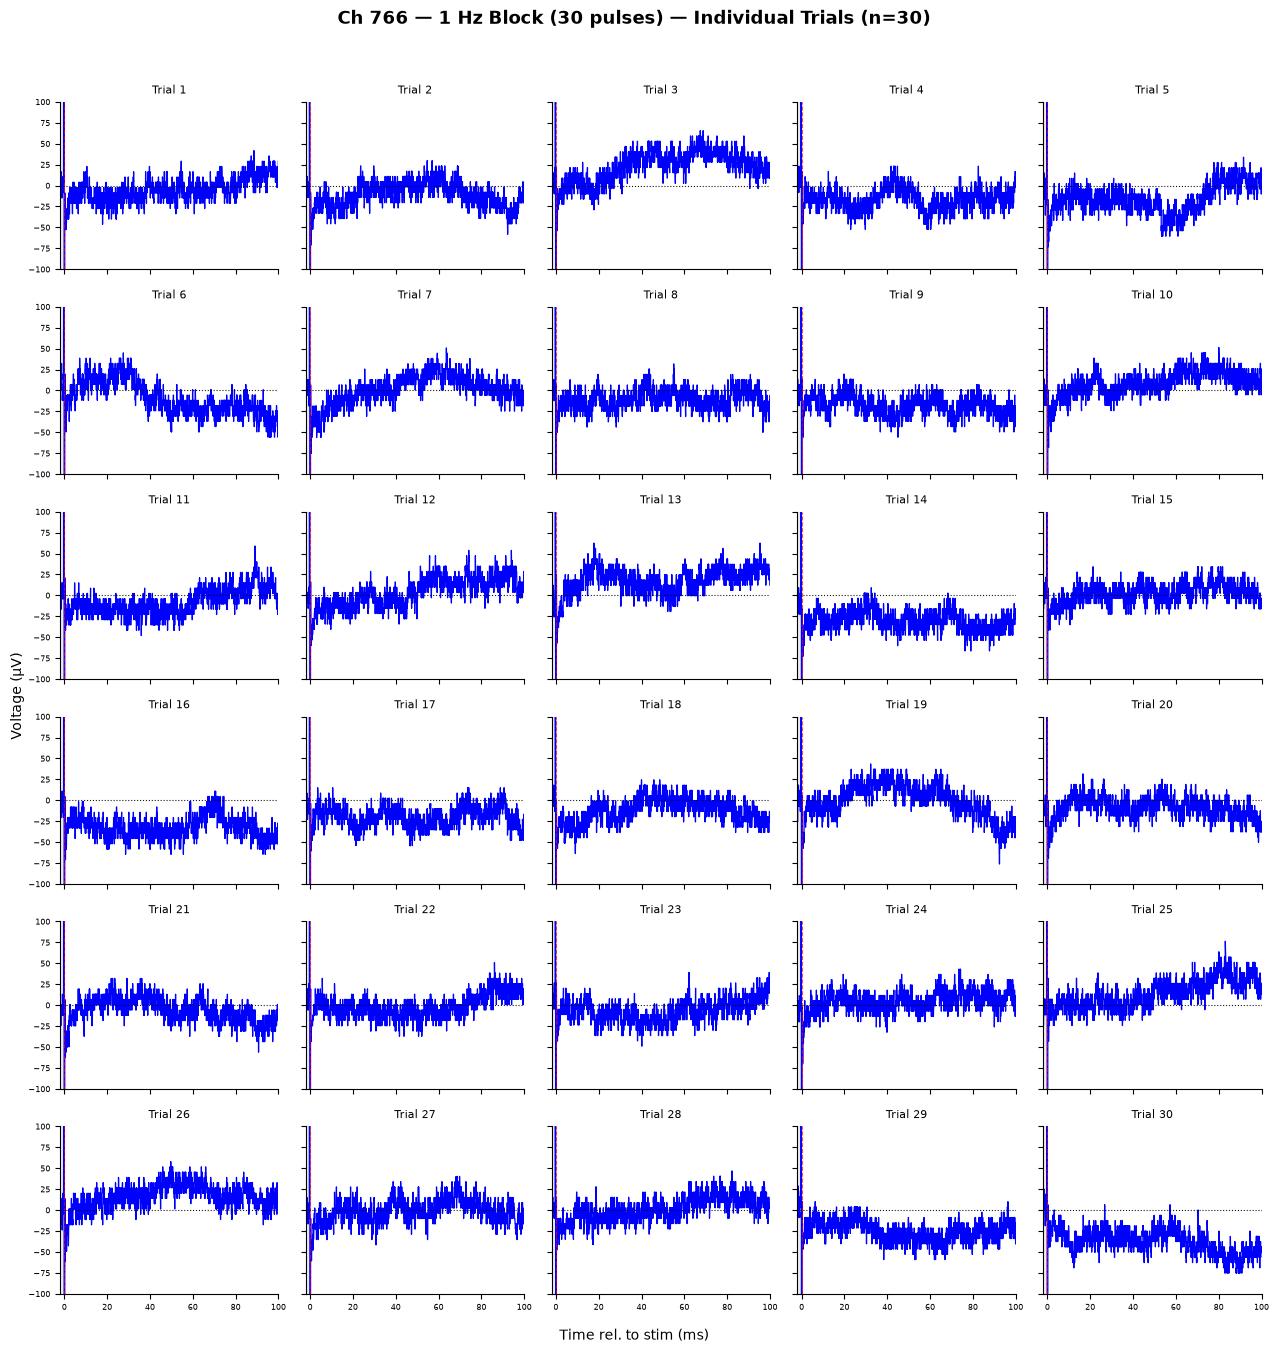

✓ Appended page for Ch 766
✓ Saved PDF: /Users/jpxmaestas/UCDavis/BenShalomLab/Analysis_pictures/EndChannels_1Hz_TrialSubplots_09_11_2026.pdf


In [10]:
print(end_channels)
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages

# ── PARAMETERS ────────────────────────────────────────────────
MAX_TRIALS_TO_PLOT = 30   # cap subplots per channel
NCOLS = 5                 # subplot grid width; rows are computed from this
COND_1HZ = CONDITIONS[0]  # 1Hz block

cond_name, t_start, t_end, cond_color = COND_1HZ
cond_key = cond_name.split(':')[0].strip()
label = FREQ_LABELS.get(cond_key, cond_name)

# ── DATA EXTRACTION ───────────────────────────────────────────
rec = recording_chunk if USE_FILTERED else recording1
fs = rec.get_sampling_frequency()
n_samp = rec.get_num_frames()

baseline_start_samps = int(BASELINE_START_MS / 1000 * fs)
baseline_end_samps = int(BASELINE_END_MS / 1000 * fs)
pre_samples = int(PRE_MS / 1000 * fs)
post_samples = int(POST_MS / 1000 * fs)
time_ms = np.arange(-pre_samples, post_samples) / fs * 1000

peak_idxs = np.round(peak_times_s * fs).astype(int)

available_ids = set(rec.get_channel_ids())
missing_channels = [ch for ch in end_channels if ch not in available_ids]
if missing_channels:
    raise ValueError(
        f"These end_channels are not present in rec (USE_FILTERED={USE_FILTERED}): "
        f"{missing_channels}. Update the end_channels list to valid ids, e.g. "
        f"{sorted(available_ids)[:10]} ..."
    )

all_traces = rec.get_traces(channel_ids=end_channels, return_in_uV=True)

# Stim timestamps belonging to the 1 Hz condition only
cond_mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
idxs_in_block = peak_idxs[cond_mask]

# ── SETUP PDF OUTPUT ──────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
date_str = datetime.now().strftime("%m_%d_%Y")
pdf_filename = f"EndChannels_1Hz_TrialSubplots_{date_str}.pdf"
pdf_path = os.path.join(OUTPUT_DIR, pdf_filename)
pdf = PdfPages(pdf_path)
print(f"Opened PDF for writing: {pdf_path}")

# ── ONE FIGURE (=ONE PDF PAGE) PER CHANNEL, TRIALS AS SUBPLOTS ─
for ch_pos, ch_id in enumerate(end_channels):
    trace = all_traces[:, ch_pos]
    trace = trace - np.median(trace)

    # Extract + baseline-correct snippets for this channel, 1Hz condition
    snippets = []
    for pk in idxs_in_block:
        block_start = pk + baseline_start_samps
        block_end = pk + baseline_end_samps
        snip_start = pk - pre_samples
        snip_end = pk + post_samples

        if block_start < 0 or snip_start < 0 or snip_end > n_samp:
            continue

        trial_baseline = trace[block_start:block_end].mean()
        snip = trace[snip_start:snip_end] - trial_baseline
        snippets.append(snip)

    snippets = np.array(snippets)
    n_trials = snippets.shape[0]
    n_to_plot = min(n_trials, MAX_TRIALS_TO_PLOT)
    ncols = min(NCOLS, max(n_to_plot, 1))
    nrows = int(np.ceil(n_to_plot / ncols)) if n_to_plot > 0 else 1

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(2.6 * ncols, 2.2 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        f'Ch {ch_id} — {label} — Individual Trials (n={n_trials})',
        fontsize=13, fontweight='bold', y=1.02,
    )

    if n_trials == 0:
        axes[0].text(0.5, 0.5, 'No Trials Detected', ha='center', va='center',
                      transform=axes[0].transAxes)
        for ax in axes[1:]:
            ax.axis('off')
    else:
        plot_idxs = np.linspace(0, n_trials - 1, n_to_plot).astype(int)

        for i, ax in enumerate(axes):
            if i >= n_to_plot:
                ax.axis('off')
                continue

            idx = plot_idxs[i]
            ax.plot(time_ms, snippets[idx], color=cond_color, lw=0.9)
            ax.axvline(0, color='red', linestyle='--', lw=0.8, alpha=0.7)
            ax.axhline(0, color='black', linestyle=':', lw=0.8, alpha=0.9, zorder=5)
            ax.axvspan(BASELINE_START_MS, BASELINE_END_MS, color='gray', alpha=0.12)
            ax.set_title(f'Trial {idx + 1}', fontsize=8)
            ax.set_xlim(-PRE_MS, POST_MS)
            ax.set_ylim(Y_MIN, Y_MAX) # 100 µvolts
            ax.tick_params(labelsize=6)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    fig.supxlabel('Time rel. to stim (ms)', fontsize=10)
    fig.supylabel('Voltage (µV)', fontsize=10)

    plt.tight_layout()
    pdf.savefig(fig, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f"✓ Appended page for Ch {ch_id}")

pdf.close()
print(f"✓ Saved PDF: {pdf_path}")


### **Stimulus Response Plots for 5 Channels:**

In [11]:
"""import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime

# Copied from previous cell output:
CONDITIONS = [
    ('Cond 1',  59.5,  90.5, 'b'),   # 30 pulses
    ('Cond 2',  119.6,  151.6, 'r'),   # 300 pulses
    ('Cond 3',  179.4,  211.6, 'g'),   # 600 pulses
]

FREQ_LABELS = {
    'Cond 1': '1Hz Block (30 pulses)',
    'Cond 2': '10 Hz Block (300 pulses)',
    'Cond 3': '20 Hz Block (600 pulses)',
}

# ── 1. USER PARAMETERS & MULTI-CHANNEL SELECTION ────────────
# List of 5 channels at varying distances from the stimulation site:
CHANNELS = ['947','566','8','157', '425'] # 


NUM_TRACES_TO_PLOT = 30     # Avoid overfilling plots

PRE_MS = 2.0  # Pre-stimulus baseline window (ms)
POST_MS = 30.0  # Post-stimulus response window (ms)
USE_FILTERED = True  # Raw vs. filtered data flag
Y_MIN = -50  # y-axis limits (uV)
Y_MAX = 50

# Baseline correction window (relative to stimulation peak at t=0 ms)
BASELINE_START_MS = -4.5
BASELINE_END_MS = -0.5

# ── 2. DATA EXTRACTION & RECORDING METRICS ───────────────────
rec = recording_chunk if USE_FILTERED else recording1
fs = rec.get_sampling_frequency()
n_samp = rec.get_num_frames()

baseline_start_samps = int(BASELINE_START_MS / 1000 * fs)
baseline_end_samps = int(BASELINE_END_MS / 1000 * fs)

pre_samples = int(PRE_MS / 1000 * fs)
post_samples = int(POST_MS / 1000 * fs)
time_ms = np.arange(-pre_samples, post_samples) / fs * 1000

peak_idxs = np.round(peak_times_s * fs).astype(int)
# Validate requested channels exist in this recording before extracting traces
available_ids = set(rec.get_channel_ids())
missing_channels = [ch for ch in CHANNELS if ch not in available_ids]
if missing_channels:
    raise ValueError(
        f"These CHANNELS are not present in rec (USE_FILTERED={USE_FILTERED}): "
        f"{missing_channels}. Update the CHANNELS list to valid ids, e.g. "
        f"{sorted(available_ids)[:10]} ..."
    )

# Extract traces for all 5 channels at once:
# Shape: (n_samples, 5) or (n_samples,) if 1 channel
all_traces = rec.get_traces(
    channel_ids=CHANNELS, return_in_uV=True
)  # (samples, n_channels)

# ── 3. GENERATE 5x3 SUBPLOT MATRIX ───────────────────────────
fig, axes = plt.subplots(
    nrows=5, ncols=3, figsize=(16, 15), sharex=True, sharey=True
)

mode_str = 'Lowpass Filtered' if USE_FILTERED else 'Raw Data'
fig.suptitle(
    f'Evoked Responses at Varying Distances from Stimulation Site— {mode_str}',
    fontsize=14,
    fontweight='bold',
    y=0.995,
)

# Loop over Rows (Channels)
for row_idx, ch_id in enumerate(CHANNELS):
    # Get trace for current channel and median-subtract
    trace = all_traces[:, row_idx]
    trace = trace - np.median(trace)

    # Loop over Columns (Conditions)
    for col_idx, (cond_name, t_start, t_end, cond_color) in enumerate(
        CONDITIONS
    ):
        ax = axes[row_idx, col_idx]

        # A. Filter stim timestamps for current condition
        cond_mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
        idxs_in_block = peak_idxs[cond_mask]

        # B. Extract and baseline-correct snippets
        snippets = []
        for pk in idxs_in_block:
            block_start = pk + baseline_start_samps
            block_end = pk + baseline_end_samps

            snip_start = pk - pre_samples
            snip_end = pk + post_samples

            if block_start < 0 or snip_start < 0 or snip_end > n_samp:
                continue

            trial_baseline = trace[block_start:block_end].mean()
            snip = trace[snip_start:snip_end] - trial_baseline
            snippets.append(snip)

        snippets = np.array(snippets)
        n_trials = snippets.shape[0]

        if n_trials == 0:
            ax.text(
                0.5,
                0.5,
                'No Trials Detected',
                ha='center',
                va='center',
                transform=ax.transAxes,
            )
            continue

        mean_trace = snippets.mean(axis=0)

        # C. Plot Individual Trials (Downsampled to NUM_TRACES_TO_PLOT)
        # Choose up to NUM_TRACES_TO_PLOT indices randomly without repetition
        num_to_select = min(NUM_TRACES_TO_PLOT, n_trials)
        selected_idxs = np.random.choice(
            n_trials, size=num_to_select, replace=False
        )

        for plot_count, idx in enumerate(selected_idxs):
            snip = snippets[idx]
            line_label = (
                f'Sampled Trials ({num_to_select}/{n_trials})'
                if plot_count == 0
                else None
            )
            ax.plot(
                time_ms,
                snip,
                color=cond_color,
                alpha=0.15,
                lw=0.6,
                zorder=2,
                label=line_label,
            )

        # D. Plot Ensemble Mean
        ax.plot(
            time_ms,
            mean_trace,
            color='black',
            lw=1.8,
            zorder=3,
            label='Ensemble Mean',
        )

        # E. Reference Lines & Baseline Shading
        ax.axvline(0, color='red', linestyle='--', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(0, color='gray', linestyle=':', lw=0.8, alpha=0.7, zorder=1)
        ax.axvspan(
            BASELINE_START_MS, BASELINE_END_MS, color='gray', alpha=0.15
        )

        # F. Subplot Specific Titles & Column/Row Labels
        if row_idx == 0:
            ax.set_title(
                f'{cond_name}\n({n_trials} trials)',
                fontsize=11,
                fontweight='bold',
            )

        if col_idx == 0:
            ax.set_ylabel(
                f'Ch {ch_id}\nVoltage (µV)', fontsize=10, fontweight='bold'
            )

        if row_idx == 4:
            ax.set_xlabel('Time rel. to stim (ms)', fontsize=10)

        # Formatting
        ax.set_xlim(-PRE_MS, POST_MS)
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.3)

        # Only put legend on top-right panel to keep grid clean
        if row_idx == 0:
            ax.legend(
                loc='upper right', frameon=True, facecolor='white', fontsize=7
            )

plt.tight_layout()

# # ── 4. SAVE PNG FILE ─────────────────────────


# plt.show()

# print(f'✓ Created and saved multi-channel grid plot: {output_filename}')

# ── Inside your analysis / plotting cell ─────────────────────

# ... [Your existing filtering, trace extraction, and subplot generation code] ...

# Ensure your suptitle dynamic header clearly labels the current filter state
mode_str = (
    f"Lowpass: 0.1-300 Hz"  # e.g., "Raw (Unfiltered)", "Lowpass 0-300Hz", etc.
)
fig.suptitle(
    f"Multi-Channel Evoked Response | {mode_str}",
    fontsize=14,
    fontweight="bold",
    y=0.99,
)

plt.tight_layout()

# ── SAVE PAGE TO PDF ─────────────────────────────────────────
# Append the current 5x3 figure as a new page in the PDF
pdf.savefig(fig, dpi=300, bbox_inches="tight")

# Display in notebook
plt.show()

# Close figure to free up memory before the next filter run
plt.close(fig)

print(f"✓ Appended page for condition: {mode_str}")"""

'import matplotlib.pyplot as plt\nimport numpy as np\nimport os\nfrom datetime import datetime\n\n# Copied from previous cell output:\nCONDITIONS = [\n    (\'Cond 1\',  59.5,  90.5, \'b\'),   # 30 pulses\n    (\'Cond 2\',  119.6,  151.6, \'r\'),   # 300 pulses\n    (\'Cond 3\',  179.4,  211.6, \'g\'),   # 600 pulses\n]\n\nFREQ_LABELS = {\n    \'Cond 1\': \'1Hz Block (30 pulses)\',\n    \'Cond 2\': \'10 Hz Block (300 pulses)\',\n    \'Cond 3\': \'20 Hz Block (600 pulses)\',\n}\n\n# ── 1. USER PARAMETERS & MULTI-CHANNEL SELECTION ────────────\n# List of 5 channels at varying distances from the stimulation site:\nCHANNELS = [\'947\',\'566\',\'8\',\'157\', \'425\'] # \n\n\nNUM_TRACES_TO_PLOT = 30     # Avoid overfilling plots\n\nPRE_MS = 2.0  # Pre-stimulus baseline window (ms)\nPOST_MS = 30.0  # Post-stimulus response window (ms)\nUSE_FILTERED = True  # Raw vs. filtered data flag\nY_MIN = -50  # y-axis limits (uV)\nY_MAX = 50\n\n# Baseline correction window (relative to stimulation peak a

In [12]:
# Close the PDF file to finalize and write to disk
pdf.close()
print(f"✓ PDF successfully finalized with all pages: {pdf_path}")

✓ PDF successfully finalized with all pages: /Users/jpxmaestas/UCDavis/BenShalomLab/Analysis_pictures/EndChannels_1Hz_TrialSubplots_09_11_2026.pdf


In [13]:


"""# Zoom windows for Insets (ms relative to stim at 0)
EAP_XLIM   = (1.0, 15.0)   # Post-stimulus window (evoked spike / fEPSP zone)
EAP_YLIM   = (-150, 150)   # Microvolts (µV)

SPONT_XLIM = (-4.5, -0.5)  # Pre-stimulus window (spontaneous noise baseline)
SPONT_YLIM = (-100, 100)   # Microvolts (µV)

# Custom Scale Bar Dimensions
MAIN_SCALEBAR_MS  = 5.0    # ms
MAIN_SCALEBAR_UV  = 500    # µV
INSET_SCALEBAR_MS = 2.0    # ms
INSET_SCALEBAR_UV = 50     # µV
# ─────────────────────────────────────────────────────────────

def add_scale_bars(ax, x_size, y_size, x_label, y_label,
                   x_unit='ms', y_unit='µV', color='black', lw=1.5, fontsize=7):
    """Draw L-shaped scale bars in the lower-left of ax data coordinates."""
    ax.autoscale(False)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]

    x0 = xlim[0] + 0.05 * x_range
    y0 = ylim[0] + 0.08 * y_range

    ax.plot([x0, x0 + x_size], [y0, y0], color=color, lw=lw, clip_on=False)
    ax.plot([x0, x0], [y0, y0 + y_size], color=color, lw=lw, clip_on=False)

    ax.text(x0 + x_size / 2, y0 - 0.04 * y_range,
            f'{x_label} {x_unit}', ha='center', va='top', fontsize=fontsize, color=color)
    ax.text(x0 - 0.02 * x_range, y0 + y_size / 2,
            f'{y_label} {y_unit}', ha='right', va='center', fontsize=fontsize,
            color=color, rotation=90)

def clean_ax(ax):
    """Remove all spines, ticks, and labels."""
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── 2. DATA EXTRACTION & BASELINE CORRECTION ────────────────
rec     = recording_chunk if USE_FILTERED else recording1
fs      = rec.get_sampling_frequency()
pre_s   = int(PRE_MS  / 1000 * fs)
post_s  = int(POST_MS / 1000 * fs)
n_samp  = rec.get_num_frames()
time_ms = np.arange(-pre_s, post_s) / fs * 1000

# Extract continuous trace for target channel
trace = rec.get_traces(channel_ids=[CHANNEL_ID], return_in_uV=True).squeeze()
trace = trace - np.median(trace)

peak_idxs = np.round(peak_times_s * fs).astype(int)
peak_amps = trace[peak_idxs]
print(f"Using {len(peak_idxs)} stim timestamps from STEP 0")

# Define sample indices for per-sweep baseline correction
baseline_win_start_ms, baseline_win_end_ms = SPONT_XLIM
baseline_start_samp = int((PRE_MS + baseline_win_start_ms) / 1000 * fs)
baseline_end_samp   = int((PRE_MS + baseline_win_end_ms)   / 1000 * fs)

# Safety check for IPI overlap
for label, t_start, t_end in CONDITIONS:
    mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
    times_in_block = peak_times_s[mask]
    inter_pulse = np.diff(times_in_block)
    if len(inter_pulse) > 0:
        ipi_ms = np.median(inter_pulse) * 1000
        if ipi_ms < PRE_MS:
            print(f"⚠️ WARNING [{FREQ_LABELS.get(label, label)}]: median IPI ({ipi_ms:.1f} ms) < PRE_MS ({PRE_MS} ms). "
                  f"Baseline window overlaps the previous pulse!")

condition_snippets = {}
dropped_counts = {}

for label, t_start, t_end in CONDITIONS:
    mask = (peak_times_s >= t_start) & (peak_times_s <= t_end)
    idxs = peak_idxs[mask]
    amps = peak_amps[mask]
    snippets  = []
    baselines = []
    n_dropped = 0
    
    for pk in idxs:
        start, end = pk - pre_s, pk + post_s
        if start < 0 or end > n_samp:
            n_dropped += 1
            continue
        snip = trace[start:end]
        baseline = snip[baseline_start_samp:baseline_end_samp].mean()
        baselines.append(baseline)
        snippets.append(snip - baseline)
        
    condition_snippets[label] = np.array(snippets) if snippets else np.empty((0, pre_s + post_s))
    dropped_counts[label] = n_dropped
    print(f"✓ {FREQ_LABELS.get(label, label)}: extracted {len(snippets)} trials")

# ── 3. PLOTTING ──────────────────────────────────────────────
n_cond = len(CONDITIONS)
colors = ['#2196F3', '#4CAF50', '#FF9800']  # Blue, Green, Orange for 3 blocks

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
axes_flat = np.array(axes).flatten()

for idx, ((label, t_start, t_end), color) in enumerate(zip(CONDITIONS, colors)):
    ax = axes_flat[idx]
    snippets = condition_snippets[label]
    disp_label = FREQ_LABELS.get(label, label)

    if snippets.shape[0] == 0:
        ax.text(0.5, 0.5, 'No trials', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{disp_label}', fontsize=10)
        clean_ax(ax)
        continue

    mean_tr = snippets.mean(axis=0)

    # --- Main Trace Overlay ---
    for s in snippets:
        ax.plot(time_ms, s, lw=0.4, alpha=0.25, color=color)
    ax.plot(time_ms, mean_tr, color='black', lw=1.5, label='Mean')
    ax.axvline(0, color='red', lw=1, ls='--', alpha=0.7)
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_xlim(-PRE_MS, POST_MS)
    ax.set_title(f'{disp_label}\n{snippets.shape[0]} trials ({t_start:.1f}–{t_end:.1f} s)', fontsize=10, fontweight='bold')
    clean_ax(ax)
    
    add_scale_bars(ax,
                   x_size=MAIN_SCALEBAR_MS, y_size=MAIN_SCALEBAR_UV,
                   x_label=MAIN_SCALEBAR_MS, y_label=MAIN_SCALEBAR_UV)

    # --- Inset 1: Post-Stimulus Response Zone (Upper Right) ---
    ax_eap = inset_axes(ax, width='45%', height='35%', loc='upper right', borderpad=1.2)
    for s in snippets:
        ax_eap.plot(time_ms, s, lw=0.4, alpha=0.25, color=color)
    ax_eap.plot(time_ms, mean_tr, color='black', lw=1.2)
    ax_eap.axvline(0, color='red', lw=0.8, ls='--', alpha=0.7)
    ax_eap.axhline(0, color='gray', lw=0.4)
    ax_eap.set_xlim(EAP_XLIM)
    ax_eap.set_ylim(EAP_YLIM)
    ax_eap.autoscale(False)
    ax_eap.set_title('Post-Stim Response', fontsize=7, pad=2)
    clean_ax(ax_eap)
    add_scale_bars(ax_eap,
                   x_size=INSET_SCALEBAR_MS, y_size=INSET_SCALEBAR_UV,
                   x_label=INSET_SCALEBAR_MS, y_label=INSET_SCALEBAR_UV,
                   fontsize=6)
    mark_inset(ax, ax_eap, loc1=2, loc2=4, fc='none', ec='gray', lw=0.6, ls='--')

    # --- Inset 2: Pre-Stimulus Baseline Zone (Lower Right) ---
    ax_spont = inset_axes(ax, width='45%', height='35%', loc='lower right', borderpad=1.2)
    for s in snippets:
        ax_spont.plot(time_ms, s, lw=0.4, alpha=0.25, color=color)
    ax_spont.plot(time_ms, mean_tr, color='black', lw=1.2)
    ax_spont.axvline(0, color='red', lw=0.8, ls='--', alpha=0.7)
    ax_spont.axhline(0, color='gray', lw=0.4)
    ax_spont.set_xlim(SPONT_XLIM)
    ax_spont.set_ylim(SPONT_YLIM)
    ax_spont.autoscale(False)
    ax_spont.set_title('Pre-Stim Baseline', fontsize=7, color='steelblue', pad=2)
    clean_ax(ax_spont)
    add_scale_bars(ax_spont,
                   x_size=INSET_SCALEBAR_MS, y_size=INSET_SCALEBAR_UV,
                   x_label=INSET_SCALEBAR_MS, y_label=INSET_SCALEBAR_UV,
                   fontsize=6)
    mark_inset(ax, ax_spont, loc1=1, loc2=3, fc='none', ec='steelblue', lw=0.6, ls='--')

mode_str = 'Bandpass Filtered' if USE_FILTERED else 'Raw Trace'
fig.suptitle(f'Channel {CHANNEL_ID} — Evoked Response Screen across Stim Conditions ({mode_str})', fontsize=12, y=1.02)
plt.savefig(f'evoked_response_channel_{CHANNEL_ID}.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()"""

SyntaxError: invalid syntax (3933819835.py, line 17)